# 1. Carga de datos

Exploracion Inicial de los datos 

In [1]:
#Importación de librerías
import pandas as pd
import numpy as np

df = pd.read_csv('../Base_de_datos.csv', sep=';', encoding='utf-8-sig')
print("Dimensiones originales:", df.shape)
df.head()

Dimensiones originales: (10763, 23)


,tipo_credito,fecha_prestamo,capital_prestado,plazo_meses,edad_cliente,tipo_laboral,salario_cliente,total_otros_prestamos,cuota_pactada,puntaje,...,saldo_mora,saldo_total,saldo_principal,saldo_mora_codeudor,creditos_sectorFinanciero,creditos_sectorCooperativo,creditos_sectorReal,promedio_ingresos_datacredito,tendencia_ingresos,Pago_atiempo
0,4,7/01/2025 14:40,1852560,12,32,Empleado,3500000,1000000,128650,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,916148.0,Creciente,1
1,4,9/01/2025 11:18,3181080,6,34,Empleado,5000000,2000000,441817,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,4473774.0,Creciente,1
2,9,26/12/2024 18:52,670200,5,34,Independiente,5000000,2000000,108632,"95,227787",...,0.0,274561.0,274561.0,NaN,2,0,1,NaN,NaN,1
3,9,4/12/2024 14:20,506807,2,25,Independiente,3000000,900000,199684,"95,227787",...,0.0,27564.0,27564.0,NaN,1,0,6,NaN,NaN,1
4,4,30/04/2025 18:41,999780,10,26,Empleado,2000000,600000,92509,"95,227787",...,0.0,0.0,NaN,NaN,0,0,0,61000.0,Creciente,1


# 2. Exploración inicial de datos

### Limitación estructural del dataset: no existe identificador de cliente

Ninguna de las 23 columnas identifica al titular del crédito. **La unidad de observación es el
crédito, no el cliente.** Esto tiene dos consecuencias que deben tenerse presentes:

1. **No es posible saber si un mismo cliente aparece en varias filas.** El 67.9% de los
   registros comparte perfil demográfico (edad + tipo laboral + salario) con al menos otro
   registro; no se puede confirmar que sean la misma persona, pero tampoco descartarlo.
2. **Advertencia para la fase de modelado:** si un mismo cliente tuviera varios créditos, un
   split aleatorio train/test colocaría al mismo cliente en ambos conjuntos, produciendo fuga
   de información y una evaluación optimista del modelo. Sin identificador no se puede aplicar
   un split agrupado por cliente (`GroupShuffleSplit`), por lo que esta limitación debe
   declararse explícitamente al reportar métricas.

## 2.1 Descripción general y caracterización de datos

El diccionario de datos es la **pieza central** de esta sección: no es solo documentación,
es una estructura de código de la que se derivan las listas de variables usadas en todo el
análisis posterior. Esto evita el error de inferir el tipo estadístico desde el tipo de dato
técnico (p. ej. tratar `tipo_credito`, que es un código nominal almacenado como entero, como
si fuera una cantidad medible).

**Clasificación de sensibilidad — marco legal colombiano:**
- La **Ley 1266 de 2008** (Habeas Data financiero) clasifica el dato financiero y crediticio
  como **semiprivado**: no tiene naturaleza íntima ni pública, y su tratamiento para cálculo
  de riesgo crediticio no requiere autorización previa del titular.
- La **Ley 1581 de 2012 (art. 5)** define los datos **sensibles** como una categoría distinta
  y más estrecha (origen racial o étnico, orientación política, convicciones religiosas,
  salud, biometría). **Ninguna variable de este dataset es sensible en ese sentido legal.**
- Autoridad de vigilancia: Superintendencia de Industria y Comercio (SIC) y Superintendencia
  Financiera de Colombia (SFC) según el caso.

In [2]:
# =============================================================================
# DICCIONARIO DE DATOS
# =============================================================================
# Estructura central del proyecto: define para cada variable su tipo de dato,
# tipo estadístico, nivel de medición, categoría funcional, sensibilidad legal
# y rol en el proyecto. El resto del notebook DERIVA sus listas de variables
# de este diccionario, en vez de inferirlas con select_dtypes() -- lo que evita
# tratar códigos categóricos como si fueran cantidades.
#
# Marco legal aplicado para la columna 'sensibilidad':
#   - Ley 1266 de 2008 (Habeas Data financiero): el dato financiero y crediticio
#     es SEMIPRIVADO (no íntimo, no público).
#   - Ley 1581 de 2012, art. 5: los datos SENSIBLES son una categoría distinta y
#     más estrecha (origen racial/étnico, orientación política, convicciones
#     religiosas, salud, biometría). Ninguna variable de este dataset lo es.

DICCIONARIO_DATOS = {
    'tipo_credito': dict(
        descripcion='Código interno de la línea o producto de crédito',
        tipo_dato='int64', tipo_variable='Cualitativa', subtipo='Nominal politómica',
        nivel_medicion='Nominal', unidad=None, valores='4, 6, 7, 9, 10, 68',
        categoria_funcional='Producto', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor categórico',
        nota='Significado de los códigos NO confirmado: no corresponde a la clasificación '
             'oficial de la Superintendencia Financiera (comercial/consumo/vivienda/microcrédito). '
             'Requiere validación con el área de producto.'),
    'fecha_prestamo': dict(
        descripcion='Fecha y hora de desembolso del crédito',
        tipo_dato='datetime64', tipo_variable='Cuantitativa', subtipo='Temporal',
        nivel_medicion='Intervalo', unidad='dd/mm/aaaa hh:mm', valores='2024-11-26 a 2026-04-26',
        categoria_funcional='Temporal', sensibilidad='Semiprivado (Ley 1266)',
        rol='Fuente de variables derivadas (mes, trimestre)'),
    'capital_prestado': dict(
        descripcion='Monto de capital desembolsado',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='360.000 a 41.444.150',
        categoria_funcional='Financiera del crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'plazo_meses': dict(
        descripcion='Plazo pactado del crédito',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta',
        nivel_medicion='Razón', unidad='meses', valores='2 a 90',
        categoria_funcional='Condiciones del crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'edad_cliente': dict(
        descripcion='Edad del cliente al momento del desembolso',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta',
        nivel_medicion='Razón', unidad='años', valores='19 a 69 (tras limpieza)',
        categoria_funcional='Demográfica', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'tipo_laboral': dict(
        descripcion='Situación laboral declarada del cliente',
        tipo_dato='object', tipo_variable='Cualitativa', subtipo='Nominal dicotómica',
        nivel_medicion='Nominal', unidad=None, valores='Empleado, Independiente',
        categoria_funcional='Demográfica / laboral', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor categórico'),
    'salario_cliente': dict(
        descripcion='Ingreso mensual declarado por el cliente',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP/mes', valores='1.000 a 18.756.570 (tras limpieza)',
        categoria_funcional='Capacidad de pago', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'total_otros_prestamos': dict(
        descripcion='Monto agregado de otras obligaciones del cliente',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Endeudamiento', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'cuota_pactada': dict(
        descripcion='Valor de la cuota mensual acordada',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP/mes', valores='23.944 en adelante',
        categoria_funcional='Condiciones del crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'puntaje_datacredito': dict(
        descripcion='Score crediticio reportado por la central de riesgo',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Discreta',
        nivel_medicion='Intervalo', unidad='puntos', valores='150 a 950 (rango oficial DataCrédito Experian)',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico',
        nota='El valor 0 NO es un score: DataCrédito confirma que no existen puntajes '
             'nulos ni negativos. Se interpreta como ausencia de historial crediticio '
             'y se trata como categoría aparte (ver sección 2.4).'),
    'cant_creditosvigentes': dict(
        descripcion='Cantidad de créditos activos del cliente',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 62',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'huella_consulta': dict(
        descripcion='Número de consultas recientes del cliente en la central de riesgo',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='consultas', valores='0 a 30',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'saldo_mora': dict(
        descripcion='Saldo actualmente en mora del cliente en el sistema',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Comportamiento de pago', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico - RIESGO DE FUGA DE INFORMACIÓN',
        nota='Debe confirmarse con el negocio si se registra ANTES del desembolso. '
             'Si se actualiza durante la vida del crédito, no puede usarse para predecir.'),
    'saldo_total': dict(
        descripcion='Saldo total pendiente del cliente en el sistema',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Endeudamiento', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'saldo_principal': dict(
        descripcion='Saldo de capital pendiente del cliente',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Endeudamiento', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'saldo_mora_codeudor': dict(
        descripcion='Saldo en mora atribuible al codeudor',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP', valores='0 en adelante',
        categoria_funcional='Comportamiento de pago', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico - RIESGO DE FUGA DE INFORMACIÓN'),
    'creditos_sectorFinanciero': dict(
        descripcion='Número de créditos del cliente en el sector financiero',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 51',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'creditos_sectorCooperativo': dict(
        descripcion='Número de créditos del cliente en el sector cooperativo',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 13',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'creditos_sectorReal': dict(
        descripcion='Número de créditos del cliente en el sector real',
        tipo_dato='int64', tipo_variable='Cuantitativa', subtipo='Discreta (conteo)',
        nivel_medicion='Razón', unidad='créditos', valores='0 a 25',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico'),
    'promedio_ingresos_datacredito': dict(
        descripcion='Ingreso promedio del cliente reportado por la central de riesgo',
        tipo_dato='float64', tipo_variable='Cuantitativa', subtipo='Continua',
        nivel_medicion='Razón', unidad='COP/mes', valores='0 en adelante',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor numérico (27% nulos, uso limitado)'),
    'tendencia_ingresos': dict(
        descripcion='Tendencia observada de los ingresos del cliente',
        tipo_dato='object', tipo_variable='Cualitativa', subtipo='Nominal politómica',
        nivel_medicion='Nominal', unidad=None,
        valores='Creciente, Decreciente, Estable, Sin_dato',
        categoria_funcional='Buró de crédito', sensibilidad='Semiprivado (Ley 1266)',
        rol='Predictor categórico'),
    'Pago_atiempo': dict(
        descripcion='Indica si el crédito se pagó a tiempo (1) o cayó en mora (0)',
        tipo_dato='int64', tipo_variable='Cualitativa', subtipo='Nominal dicotómica',
        nivel_medicion='Nominal', unidad=None, valores='0, 1',
        categoria_funcional='Resultado', sensibilidad='Semiprivado (Ley 1266)',
        rol='VARIABLE OBJETIVO (target)'),
}

# -----------------------------------------------------------------------------
# Listas derivadas del diccionario. TODO el análisis posterior las usa.
# -----------------------------------------------------------------------------
TARGET = 'Pago_atiempo'

VARS_CATEGORICAS = [v for v, d in DICCIONARIO_DATOS.items()
                    if d['tipo_variable'] == 'Cualitativa']
VARS_NUMERICAS = [v for v, d in DICCIONARIO_DATOS.items()
                  if d['tipo_variable'] == 'Cuantitativa' and d['subtipo'] != 'Temporal']
VARS_TEMPORALES = [v for v, d in DICCIONARIO_DATOS.items() if d['subtipo'] == 'Temporal']
VARS_MONETARIAS = [v for v, d in DICCIONARIO_DATOS.items() if d.get('unidad') in ('COP', 'COP/mes')]
VARS_RIESGO_FUGA = [v for v, d in DICCIONARIO_DATOS.items() if 'FUGA' in d['rol']]

# Vista tabular del diccionario
tabla_dicc = pd.DataFrame([
    {'Variable': v, 'Tipo dato': d['tipo_dato'], 'Tipo variable': d['tipo_variable'],
     'Subtipo': d['subtipo'], 'Nivel medición': d['nivel_medicion'],
     'Unidad': d['unidad'] or '-', 'Categoría funcional': d['categoria_funcional'],
     'Rol': d['rol']}
    for v, d in DICCIONARIO_DATOS.items()
])

pd.set_option('display.max_colwidth', 42)
print(tabla_dicc.to_string(index=False))

print(f"\nVariables categóricas ({len(VARS_CATEGORICAS)}): {VARS_CATEGORICAS}")
print(f"\nVariables numéricas ({len(VARS_NUMERICAS)}): {VARS_NUMERICAS}")
print(f"\nVariables temporales: {VARS_TEMPORALES}")
print(f"\nVariables con riesgo de fuga de información: {VARS_RIESGO_FUGA}")


                     Variable  Tipo dato Tipo variable            Subtipo Nivel medición           Unidad     Categoría funcional                                                Rol
                 tipo_credito      int64   Cualitativa Nominal politómica        Nominal                -                Producto                               Predictor categórico
               fecha_prestamo datetime64  Cuantitativa           Temporal      Intervalo dd/mm/aaaa hh:mm                Temporal     Fuente de variables derivadas (mes, trimestre)
             capital_prestado      int64  Cuantitativa           Continua          Razón              COP  Financiera del crédito                                 Predictor numérico
                  plazo_meses      int64  Cuantitativa           Discreta          Razón            meses Condiciones del crédito                                 Predictor numérico
                 edad_cliente      int64  Cuantitativa           Discreta          Razón       

## 2.2 Unificar la forma como se representan los valores Nulos

**Tratamiento de nulos**
Conclusión de negocio: cuando un cliente tiene cant_creditosvigentes = 0 (este crédito es el único que tiene, no hay otros créditos activos), los campos que agregan información de otros créditos simplemente no tienen nada que sumar por ende no es un dato perdido por error, es la ausencia lógica de algo que no existe. El tratamiento correcto aquí no es la mediana (que sugeriría "no sabemos el valor"), sino cero (que dice correctamente "no hay saldo porque no hay otro crédito").

lo tratamos con un 0

In [3]:
# saldo_principal, saldo_mora, saldo_total, saldo_mora_codeudor:
# nulos = ausencia estructural (cliente sin otros creditos / sin codeudor), no error.
# Se imputan con 0, con trazabilidad de qué filas se tocaron.

columnas_saldo = ['saldo_principal', 'saldo_mora', 'saldo_total', 'saldo_mora_codeudor']

for col in columnas_saldo:
    df[f'{col}_era_nulo'] = df[col].isnull()
    df[col] = df[col].fillna(0)

print("Nulos restantes en columnas de saldo:")
print(df[columnas_saldo].isnull().sum())

print("\nVerificación - relación con cant_creditosvigentes=0:")
print(df.groupby(df['saldo_principal_era_nulo'])['cant_creditosvigentes'].median())

Nulos restantes en columnas de saldo:
saldo_principal        0
saldo_mora             0
saldo_total            0
saldo_mora_codeudor    0
dtype: int64

Verificación - relación con cant_creditosvigentes=0:
saldo_principal_era_nulo
False    5.0
True     0.0
Name: cant_creditosvigentes, dtype: float64


se analiza que se hacen con Nulos en promedio_ingresos_datacredito, tendencia_ingresos y puntaje_datacredito

promedio_ingresos_datacredito y tendencia_ingresos (~27% nulos cada uno, prácticamente las mismas filas) Con más de una cuarta parte de los datos ausentes, imputar con la media o mediana sería inventar el 27% de una variable  eso distorsiona cualquier análisis o modelo que la use después.
Es por eso que  aquí la pratica ideeal seria no fabricar el valor: se deja el número como está (NaN) pero creamos una bandera explícita que indique "este dato no está disponible", para que cualquier análisis posterior lo maneje con conocimiento de causa, y agregamos una categoría explícita Sin_dato en la variable categórica
puntaje_datacredito (0.06%, solo 6 registros) imputar con la mediana

In [4]:
# promedio_ingresos_datacredito: alto % de nulos, sin causa estructural clara.
# NO se imputa con un valor inventado; se deja el NaN y se marca con bandera explícita.
df['promedio_ingresos_datacredito_era_nulo'] = df['promedio_ingresos_datacredito'].isnull()

# tendencia_ingresos: mismo caso, se usa categoría explícita "Sin_dato"
# en vez de imputar con la moda (que fabricaría una tendencia que no conocemos).
df['tendencia_ingresos'] = df['tendencia_ingresos'].fillna('Sin_dato')

# puntaje_datacredito: nulos insignificantes (0.06%), se imputa con mediana sin riesgo.
mediana_puntaje_dc = df['puntaje_datacredito'].median()
df['puntaje_datacredito'] = df['puntaje_datacredito'].fillna(mediana_puntaje_dc)

print("Nulos restantes en todo el dataset:")
print(df.isnull().sum()[df.isnull().sum() > 0])

Nulos restantes en todo el dataset:
promedio_ingresos_datacredito    2930
dtype: int64


## 2.3 Eliminación de variables irrelevantes

In [5]:

# Evaluar candidatas a eliminar: revisar varianza/cardinalidad de cada columna
print("Cardinalidad (valores únicos) por columna:")
print(df.nunique().sort_values())

Cardinalidad (valores únicos) por columna:
tipo_laboral                                  2
saldo_total_era_nulo                          2
saldo_mora_codeudor_era_nulo                  2
promedio_ingresos_datacredito_era_nulo        2
saldo_mora_era_nulo                           2
Pago_atiempo                                  2
saldo_principal_era_nulo                      2
saldo_mora_codeudor                           4
tipo_credito                                  6
creditos_sectorCooperativo                   11
plazo_meses                                  18
creditos_sectorReal                          24
huella_consulta                              28
creditos_sectorFinanciero                    33
cant_creditosvigentes                        39
tendencia_ingresos                           47
edad_cliente                                 54
saldo_mora                                   55
puntaje                                     248
puntaje_datacredito                         3

In [6]:
# 'puntaje' concentra el 87.4% de sus valores en un único número (95.227787),
# comportándose casi como una constante -> capacidad predictiva casi nula.
# Se elimina, dejando trazabilidad de la decisión documentada aquí.
# Se verifica primero que exista, para que la celda sea segura de ejecutar
if 'puntaje' in df.columns:
    print("Antes de eliminar:", df.shape[1], "columnas")
    df = df.drop(columns=['puntaje'])
    print("Después de eliminar 'puntaje':", df.shape[1], "columnas")
else:
    print("'puntaje' ya fue eliminada previamente. Columnas actuales:", df.shape[1])

Antes de eliminar: 28 columnas
Después de eliminar 'puntaje': 27 columnas


## Hallazgos — Eliminación de variables irrelevantes

- **`puntaje` eliminada**: 87.4% de los registros comparten exactamente el mismo valor (95.227787), comportándose como una constante sin poder discriminante real. Se descarta como variable de baja calidad.
- **`saldo_total`**: se evaluó como posible redundante de `saldo_principal + saldo_mora` (coincide en 83.8% de los casos), pero se conserva porque en el 16.2% restante aporta información adicional no explicada por la suma simple.
- El resto de las variables tiene cardinalidad razonable y relación clara con el negocio; no se identificaron más candidatas a eliminar en esta fase.

## 2.4 Convertir los datos en su tipo correcto y corrección de los datos

*Nota: la conversión de `puntaje` se omite aquí porque la columna fue eliminada en la sección 2.3 (baja calidad predictiva, 87.4% de valores idénticos).*

In [7]:
# Corregir 'fecha_prestamo': texto -> datetime
df['fecha_prestamo'] = pd.to_datetime(df['fecha_prestamo'], format='%d/%m/%Y %H:%M', errors='coerce')

print("Tipo de 'fecha_prestamo' después de la conversión:", df['fecha_prestamo'].dtype)
print("Fechas nulas tras la conversión (errores de formato):", df['fecha_prestamo'].isnull().sum())
print("Rango de fechas:", df['fecha_prestamo'].min(), "a", df['fecha_prestamo'].max())

Tipo de 'fecha_prestamo' después de la conversión: datetime64[us]
Fechas nulas tras la conversión (errores de formato): 0
Rango de fechas: 2024-11-26 09:17:00 a 2026-04-26 18:43:00


### Corrección de `puntaje_datacredito`: el valor 0 no es un score

El diccionario de datos establece que el rango oficial del score de DataCrédito Experian es
**150 a 950**. DataCrédito afirma expresamente que no existen puntajes nulos ni negativos.

Los valores fuera de ese rango, por tanto, **no son scores bajos: son ausencia de score**.
Tratarlos como el número 0 introduce un error grave, porque el modelo interpretaría a un
cliente sin historial crediticio como si tuviera el peor score posible, cuando en realidad
son situaciones distintas.

In [8]:
# Rango oficial del score DataCrédito Experian (fuente: Términos y Condiciones Midatacrédito)
SCORE_MIN, SCORE_MAX = 150, 950

fuera_rango = (df['puntaje_datacredito'] < SCORE_MIN) | (df['puntaje_datacredito'] > SCORE_MAX)

print("=== Diagnóstico de puntaje_datacredito frente al rango oficial [150, 950] ===")
print(f"Registros por debajo de {SCORE_MIN}: {(df['puntaje_datacredito'] < SCORE_MIN).sum()}")
print(f"Registros por encima de {SCORE_MAX}: {(df['puntaje_datacredito'] > SCORE_MAX).sum()}")
print(f"TOTAL fuera de rango: {fuera_rango.sum()} ({fuera_rango.mean()*100:.2f}%)")
print("\nValores concretos fuera de rango:")
print(df.loc[fuera_rango, 'puntaje_datacredito'].value_counts().sort_index())

# Comportamiento de pago del grupo sin score válido
print("\n=== ¿El grupo sin score válido se comporta distinto? ===")
tasa_sin = (1 - df.loc[fuera_rango, 'Pago_atiempo'].mean()) * 100
tasa_con = (1 - df.loc[~fuera_rango, 'Pago_atiempo'].mean()) * 100
print(f"Tasa de mora SIN score válido: {tasa_sin:.2f}%  (n={fuera_rango.sum()})")
print(f"Tasa de mora CON score válido: {tasa_con:.2f}%  (n={(~fuera_rango).sum()})")
print(f"Diferencia: {tasa_sin - tasa_con:+.2f} puntos porcentuales")

=== Diagnóstico de puntaje_datacredito frente al rango oficial [150, 950] ===
Registros por debajo de 150: 147
Registros por encima de 950: 6
TOTAL fuera de rango: 153 (1.42%)

Valores concretos fuera de rango:
puntaje_datacredito
-7.0        1
 0.0      145
 7.0        1
 951.0      1
 968.0      1
 969.0      1
 978.0      1
 987.0      1
 999.0      1
Name: count, dtype: int64

=== ¿El grupo sin score válido se comporta distinto? ===
Tasa de mora SIN score válido: 6.54%  (n=153)
Tasa de mora CON score válido: 4.72%  (n=10610)
Diferencia: +1.81 puntos porcentuales


In [9]:
# Tratamiento: se crea una bandera explícita y el score inválido pasa a NaN.
# NO se imputa con 0 ni con la mediana: la ausencia de historial es información
# en sí misma y debe poder distinguirse de un score bajo real.

df['sin_historial_crediticio'] = fuera_rango.astype(int)
df.loc[fuera_rango, 'puntaje_datacredito'] = pd.NA
df['puntaje_datacredito'] = pd.to_numeric(df['puntaje_datacredito'], errors='coerce')

print("Después del tratamiento:")
print(f"  Registros marcados como sin historial: {df['sin_historial_crediticio'].sum()}")
print(f"  Rango del score válido: {df['puntaje_datacredito'].min():.0f} a {df['puntaje_datacredito'].max():.0f}")
print(f"  Nulos en puntaje_datacredito (intencionales): {df['puntaje_datacredito'].isnull().sum()}")

Después del tratamiento:
  Registros marcados como sin historial: 153
  Rango del score válido: 287 a 947
  Nulos en puntaje_datacredito (intencionales): 153


**Hallazgo:** los 153 registros sin score válido presentan una tasa de mora de **6.54%**
frente al **4.72%** de quienes sí tienen score. La ausencia de historial crediticio es, en sí
misma, una señal de riesgo — un cliente sobre el que la central de riesgo no tiene información
suficiente resulta más propenso al incumplimiento en estos datos.

Este hallazgo **solo fue posible al definir formalmente el rango válido en el diccionario de
datos**: sin él, los 145 registros con valor `0` se habrían analizado como scores legítimos
extremadamente bajos, mezclando dos poblaciones distintas.

# atipicos en edad_cliente
Se trata y lo recomendable seriacomo dato faltante (NaN) e imputar debido a que la edad es inválida, no confiable, pero el resto del registro sí lo es. Imputamos con la mediana (robusta a atípicos) y dejamos trazabilidad de qué se imputó.
ademas se crea una columna booleana que marque qué registros fueron corregidos, para no esconder dicha intervencion


In [10]:
# Investigar el patrón de los atípicos de edad antes de decidir
print("Distribución de edades > 80:")
print(df[df['edad_cliente'] > 80]['edad_cliente'].value_counts().sort_index())

Distribución de edades > 80:
edad_cliente
121      4
122    144
123      2
Name: count, dtype: int64


In [11]:
# Umbral de corte: no hay registros entre 70 y 120, así que >90 captura
# limpiamente solo los atípicos (121, 122, 123), sin tocar edades reales
UMBRAL_EDAD = 90

# Trazabilidad establecidad
df['edad_cliente_corregida'] = df['edad_cliente'] > UMBRAL_EDAD

print("Registros marcados para corrección:", df['edad_cliente_corregida'].sum())

# Guarde la mediana calculada SOLO con datos válidos (excluyendo el error)
mediana_edad = df.loc[~df['edad_cliente_corregida'], 'edad_cliente'].median()
print("Mediana de edad (con datos válidos):", mediana_edad)

# Imputar es decir se reemplaza los atípicos por la mediana
df.loc[df['edad_cliente_corregida'], 'edad_cliente'] = mediana_edad

print("\nVerificación después de la corrección:")
print(df['edad_cliente'].describe())

Registros marcados para corrección: 150
Mediana de edad (con datos válidos): 42.0

Verificación después de la corrección:
count    10763.000000
mean        42.833875
std         11.864169
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64


Hacemos un tratamiento de salario en este caso es necesario
revisar la distribucion que existe ya que el percentil 99 (39.5m)  y el 99.5 (276M)
Se realizar el interquartilico a ver

In [12]:
# Método IQR (Tukey) para detectar atípicos de forma estadísticamente fundamentada
Q1 = df['salario_cliente'].quantile(0.25)
Q3 = df['salario_cliente'].quantile(0.75)
IQR = Q3 - Q1

limite_superior = Q3 + 1.5 * IQR
limite_inferior = Q1 - 1.5 * IQR

print(f"Q1: {Q1:,.0f} | Q3: {Q3:,.0f} | IQR: {IQR:,.0f}")
print(f"Límite superior (Q3 + 1.5*IQR): {limite_superior:,.0f}")
print(f"Límite inferior: {limite_inferior:,.0f}")

print(f"\nRegistros por encima del límite superior: {(df['salario_cliente'] > limite_superior).sum()}")
print(f"Registros con salario = 0: {(df['salario_cliente'] == 0).sum()}")

Q1: 2,000,000 | Q3: 4,875,808 | IQR: 2,875,808
Límite superior (Q3 + 1.5*IQR): 9,189,520
Límite inferior: -2,313,712

Registros por encima del límite superior: 718
Registros con salario = 0: 24


entonces tenemos que variables monetarias así de sesgadas es ideal aplicar el IQR sobre la escala logarítmica (transformación log), que nos comprime la cola larga y hace que el método funcione correctamente.

In [13]:
# El IQR sobre escala original sobre-marca salarios altos pero legítimos
# (la distribución de salario es naturalmente asimétrica). Usamos log-transform,
# técnica estándar para variables monetarias sesgadas, antes de aplicar IQR.

# Separamos los ceros (se tratan aparte, no tiene sentido incluirlos en el log)
mask_valido = df['salario_cliente'] > 0
log_salario = np.log(df.loc[mask_valido, 'salario_cliente'])

Q1_log = log_salario.quantile(0.25)
Q3_log = log_salario.quantile(0.75)
IQR_log = Q3_log - Q1_log
limite_superior_log = Q3_log + 1.5 * IQR_log
limite_superior = np.exp(limite_superior_log)

print(f"Límite superior (log-IQR): {limite_superior:,.0f}")

# Trazabilidad: marcar filas corregidas (salario=0 O por encima del límite)
df['salario_cliente_corregido'] = (df['salario_cliente'] == 0) | (df['salario_cliente'] > limite_superior)

print("Registros marcados para corrección:", df['salario_cliente_corregido'].sum())

# Mediana calculada solo con datos válidos (ni ceros ni atípicos)
mediana_salario = df.loc[~df['salario_cliente_corregido'], 'salario_cliente'].median()
print("Mediana de salario (datos válidos):", f"{mediana_salario:,.0f}")

# Imputar
df.loc[df['salario_cliente_corregido'], 'salario_cliente'] = mediana_salario

print("\nVerificación después de la corrección:")
print(df['salario_cliente'].describe())

Límite superior (log-IQR): 18,790,797
Registros marcados para corrección: 250
Mediana de salario (datos válidos): 3,000,000

Verificación después de la corrección:
count    1.076300e+04
mean     3.650006e+06
std      2.546061e+06
min      1.000000e+03
25%      2.000000e+06
50%      3.000000e+06
75%      4.500000e+06
max      1.875657e+07
Name: salario_cliente, dtype: float64


## Limpieza — Atípicos edad_cliente y salario_cliente

- **edad_cliente**: 150 registros con valores imposibles (121-123 años) detectados por salto claro en la distribución (sin datos entre 70 y 120). Imputados con la mediana (42 años) de los datos válidos. Trazabilidad en `edad_cliente_corregida`.
- **salario_cliente**: el método IQR estándar mostraba salarios altos pero legítimos (6.7% de los datos) por la asimetría natural de la variable. Se aplica IQR sobre escala logarítmica , resultando en un límite de $18.79M y 250 registros corregidos (226 atípicos altos + 24 en cero). Imputados con la mediana ($3M) de los datos válidos. Trazabilidad en `salario_cliente_corregido`.
- **Hallazgo duda : el nuevo mínimo tras la corrección es $1.000 — no cumple los criterios de corrección definidos (no es cero, no supera el límite superior), pero no es un salario mensual creíble. Se deja documentado para una futura revisión de reglas de negocio más finas.


# correcion de tendencias de ingresos
Existe y se evidencia que los 58 registros corruptos tienen promedio_ingresos_datacredito poblado al 100%  no es coincidencia.
Los valores corruptos incluyen números positivos, negativos y ceros (ej. 8315, -224714, 0).
teoria y es que :
probablemente se calculaba originalmente como un valor numérico de variación de ingresos (positivo = creció, negativo = decreció, cero = estable), y luego un proceso automático lo convertía a categoría (Creciente/Decreciente/Estable). Para estos 58 registros, esa conversión falló y quedó el número crudo sin categorizar

Decision tomada : Reconstruir datos es decir la categoría usando el signo del número , no una invención: si el patrón de las categorías reales (Creciente, Decreciente, Estable) 

In [14]:
categorias_validas = {'Creciente', 'Decreciente', 'Estable', 'Sin_dato'}
mask_corrupto = df['tendencia_ingresos'].notna() & ~df['tendencia_ingresos'].isin(categorias_validas)

print("Registros corruptos detectados:", mask_corrupto.sum())

# Reconstrucción basada en el signo del valor numérico (supuesto documentado:
# tendencia_ingresos originalmente representaba variación numérica de ingresos)
valores_numericos = pd.to_numeric(df.loc[mask_corrupto, 'tendencia_ingresos'], errors='coerce')

def clasificar_tendencia(v):
    if v > 0:
        return 'Creciente'
    elif v < 0:
        return 'Decreciente'
    else:
        return 'Estable'

# Trazabilidad
df['tendencia_ingresos_reconstruida'] = mask_corrupto

# Reconstrucción
df.loc[mask_corrupto, 'tendencia_ingresos'] = valores_numericos.apply(clasificar_tendencia)

print("\nDistribución final de 'tendencia_ingresos':")
print(df['tendencia_ingresos'].value_counts(dropna=False))

Registros corruptos detectados: 58

Distribución final de 'tendencia_ingresos':
tendencia_ingresos
Creciente      5335
Sin_dato       2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64


Creciente subió de 5294→5335, Decreciente de 1291→1301, Estable de 1188→1195; suman los 58), y los 2.932 NaN

## Limpieza — tendencia_ingresos (valores corruptos)

- Se detectaron 58 registros con valores numéricos en vez de categoría, y el 100% de ellos tenía `promedio_ingresos_datacredito` poblado — indicio de que `tendencia_ingresos` se derivaba originalmente de un valor numérico de variación de ingresos, y el proceso de categorización falló para estos casos.
- **Reconstrucción aplicada**: se clasificó cada valor corrupto según su signo (positivo → Creciente, negativo → Decreciente, cero → Estable), replicando la lógica de negocio esperada en vez de descartar la información.
- Trazabilidad en la columna `tendencia_ingresos_reconstruida`.
- Los 2.932 valores nulos originales (27.24%) aun no se modifico en este paso entonces se tratarán en el paso de nulos junto con las demás columnas.

# 3. Exploración de datos y descripción (EDA)

## 3.1 Análisis univariado

In [15]:
# Duplicados
print("Filas duplicadas exactas:", df.duplicated().sum())

# Nulos por columna
print("\nValores nulos por columna:")
nulos = df.isnull().sum()
nulos_pct = (nulos / len(df) * 100).round(2)
resumen_nulos = pd.DataFrame({'nulos': nulos, 'porcentaje': nulos_pct})
print(resumen_nulos[resumen_nulos['nulos'] > 0])

# Nota: revisión de 'puntaje' omitida — columna eliminada en 2.3 (baja calidad predictiva)

# Revisión de 'tendencia_ingresos'
print("\nValores únicos en 'tendencia_ingresos':")
print(df['tendencia_ingresos'].value_counts())

Filas duplicadas exactas: 0

Valores nulos por columna:
                               nulos  porcentaje
puntaje_datacredito              153        1.42
promedio_ingresos_datacredito   2930       27.22

Valores únicos en 'tendencia_ingresos':
tendencia_ingresos
Creciente      5335
Sin_dato       2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64


## Hallazgos — Calidad de datos

- **Duplicados**: 0 filas duplicadas
- **Nulos relevantes**:
  - `promedio_ingresos_datacredito` (27.22%) y `tendencia_ingresos` (27.24%): alto porcentaje de nulos
  - `saldo_mora_codeudor` (5.48%), `saldo_principal` (3.76%), `saldo_mora`/`saldo_total` (1.45%): nulos menores, posiblemente créditos sin codeudor o sin saldo registrado.
  - `puntaje_datacredito` (0.06%): nulos mínimos detectados
- **`puntaje` mal formateado**: está almacenada como texto (`str`) con coma decimal (ej. `'95,227787'`) en vez de número.entonces debe convertirse a `float` reemplazando la coma por punto.
- **`tendencia_ingresos` corrupta**: además de las 3 categorías esperadas (`Creciente`, `Decreciente`, `Estable`), existen valores numéricos sueltos (ej. `8315`, `1000000`, `-224714`) que no corresponden a una categoría válida — indica un problema de origen en los datos como tal

In [16]:
# Atípicos en edad
print("=== Edad ===")
print(df['edad_cliente'].describe())
print("\nRegistros con edad > 90:")
print(df[df['edad_cliente'] > 90]['edad_cliente'].value_counts())

# Atípicos en salario
print("\n=== Salario ===")
print(df['salario_cliente'].describe())
print("\nRegistros con salario en cero:", (df['salario_cliente'] == 0).sum())
print("Registros con salario > 50,000,000:", (df['salario_cliente'] > 50_000_000).sum())
print("\nTop 10 salarios más altos:")
print(df['salario_cliente'].sort_values(ascending=False).head(10))

=== Edad ===
count    10763.000000
mean        42.833875
std         11.864169
min         19.000000
25%         33.000000
50%         42.000000
75%         52.000000
max         69.000000
Name: edad_cliente, dtype: float64

Registros con edad > 90:
Series([], Name: count, dtype: int64)

=== Salario ===
count    1.076300e+04
mean     3.650006e+06
std      2.546061e+06
min      1.000000e+03
25%      2.000000e+06
50%      3.000000e+06
75%      4.500000e+06
max      1.875657e+07
Name: salario_cliente, dtype: float64

Registros con salario en cero: 0
Registros con salario > 50,000,000: 0

Top 10 salarios más altos:
10592    18756573
4441     18490000
5391     18258000
324      18200000
6147     18000000
494      18000000
4547     18000000
6315     18000000
1210     18000000
4974     18000000
Name: salario_cliente, dtype: int64


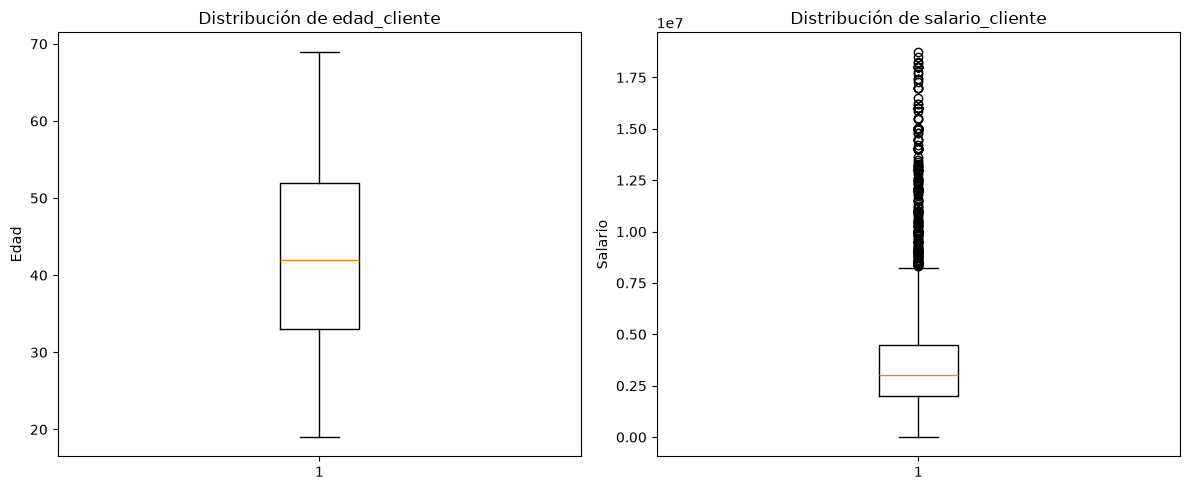

In [17]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].boxplot(df['edad_cliente'].dropna())
axes[0].set_title('Distribución de edad_cliente')
axes[0].set_ylabel('Edad')

axes[1].boxplot(df['salario_cliente'].dropna())
axes[1].set_title('Distribución de salario_cliente')
axes[1].set_ylabel('Salario')

plt.tight_layout()
plt.show()

#### Observaciones de los boxplots

la caja abarca del percentil 25 al 75 (el 50% central de los datos), la
línea interior es la mediana, los bigotes se extienden hasta 1,5 veces el rango intercuartílico, y
los puntos sueltos por fuera son valores atípicos.

**`edad_cliente`:** la caja se sitúa entre los 33 y los 53 años con mediana en 42, y el bigote
superior llega hasta cerca de los 69. Por encima, separados por un espacio vacío considerable,
aparecen los puntos correspondientes a las edades de 121 a 123 años. **Ese espacio vacío entre
los 70 y los 120 años es la evidencia clave**: no hay una transición gradual hacia esos valores,
lo que descarta que sean clientes mayores reales y apunta a un valor centinela o error de
captura.

**`salario_cliente`:** la caja aparece comprimida contra el eje inferior y los valores atípicos se
extienden muy por encima. La escala del gráfico está dominada por unos pocos registros con
salarios de miles de millones, que aplastan visualmente al 95% restante de los datos. A
diferencia del caso de la edad, aquí **no hay un espacio vacío que separe lo válido de lo
inválido**: la transición es continua, razón por la cual no se pudo fijar un umbral a ojo y se
recurrió al método IQR sobre escala logarítmica.

## Hallazgos — Atípicos

- **Edad**: 150 registros (1.4%) con edad entre 121 y 123 años — valor imposible, probablemente  error o valor capturado por el sistema de originación. El resto de la distribución es coherente (min 19, max real ~68-70, mediana 42).
- **Salario**: distribución extremadamente asimétrica. La mediana es de ~$3.000.000, pero existen 97 registros con salario > $50.000.000 mensuales, llegando hasta $22.000 millones poco creíbles como ingreso mensual real. Posible error de digitación (ej. salario anual capturado como mensual).
- Ambos casos se trataran en la fase de limpieza.

In [18]:
# Las variables analizadas se toman del DICCIONARIO DE DATOS, no de select_dtypes().
# Motivo: 'tipo_credito' y 'Pago_atiempo' son códigos categóricos almacenados como enteros;
# calcular su media, desviación o asimetría no tiene significado estadístico.
numericas = [c for c in VARS_NUMERICAS if c in df.columns]

print(f"Variables numéricas analizadas ({len(numericas)}): {numericas}")
print(f"\nExcluidas por ser categóricas (aunque su dtype sea entero): "
      f"{[c for c in VARS_CATEGORICAS if c in df.columns]}")

print("\n=== Describe() completo ===")
print(df[numericas].describe().T)

print("\n=== Medidas de dispersión avanzadas ===")
from scipy import stats
dispersion = pd.DataFrame({
    'rango': df[numericas].max() - df[numericas].min(),
    'IQR': df[numericas].quantile(0.75) - df[numericas].quantile(0.25),
    'varianza': df[numericas].var(),
    'desv_estandar': df[numericas].std(),
    'skewness': df[numericas].apply(lambda x: stats.skew(x.dropna())),
    'kurtosis': df[numericas].apply(lambda x: stats.kurtosis(x.dropna())),
})
print(dispersion.round(3))

Variables numéricas analizadas (17): ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente', 'total_otros_prestamos', 'cuota_pactada', 'puntaje_datacredito', 'cant_creditosvigentes', 'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal', 'saldo_mora_codeudor', 'creditos_sectorFinanciero', 'creditos_sectorCooperativo', 'creditos_sectorReal', 'promedio_ingresos_datacredito']

Excluidas por ser categóricas (aunque su dtype sea entero): ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

=== Describe() completo ===
                                 count          mean           std       min  \
capital_prestado               10763.0  2.434315e+06  1.909643e+06  360000.0   
plazo_meses                    10763.0  1.057558e+01  6.632082e+00       2.0   
edad_cliente                   10763.0  4.283388e+01  1.186417e+01      19.0   
salario_cliente                10763.0  3.650006e+06  2.546061e+06    1000.0   
total_otros_prestamos          10763

In [19]:
# Análisis univariado de variables CATEGÓRICAS: tablas de frecuencia
print("=== Tablas de frecuencia (variables categóricas) ===")
for col in [c for c in VARS_CATEGORICAS if c in df.columns]:
    frec = df[col].value_counts(dropna=False)
    frec_rel = df[col].value_counts(dropna=False, normalize=True).mul(100).round(2)
    tabla = pd.DataFrame({'frecuencia': frec, 'porcentaje_%': frec_rel})
    print(f"\n--- {col} ---")
    print(tabla)

=== Tablas de frecuencia (variables categóricas) ===

--- tipo_credito ---
              frecuencia  porcentaje_%
tipo_credito                          
4                   7747         71.98
9                   2876         26.72
10                   116          1.08
6                     21          0.20
7                      2          0.02
68                     1          0.01

--- tipo_laboral ---
               frecuencia  porcentaje_%
tipo_laboral                           
Empleado             6754         62.75
Independiente        4009         37.25

--- tendencia_ingresos ---
                    frecuencia  porcentaje_%
tendencia_ingresos                          
Creciente                 5335         49.57
Sin_dato                  2932         27.24
Decreciente               1301         12.09
Estable                   1195         11.10

--- Pago_atiempo ---
              frecuencia  porcentaje_%
Pago_atiempo                          
1                  10252         

In [20]:
# Tablas pivote: resumen de variables numéricas agregadas por categoría.
# Complementan las tablas de frecuencia en el análisis univariado.
print("=== Tabla pivote: estadísticos de capital y cuota por tipo de crédito ===")
pivote_credito = df.pivot_table(
    index='tipo_credito',
    values=['capital_prestado', 'cuota_pactada', 'plazo_meses'],
    aggfunc=['mean', 'median', 'count']
).round(0)
print(pivote_credito)

print("\n=== Tabla pivote: perfil del cliente por tipo laboral ===")
pivote_laboral = df.pivot_table(
    index='tipo_laboral',
    values=['edad_cliente', 'salario_cliente', 'cant_creditosvigentes'],
    aggfunc=['mean', 'median']
).round(0)
print(pivote_laboral)

=== Tabla pivote: estadísticos de capital y cuota por tipo de crédito ===
                         mean                                     median  \
             capital_prestado cuota_pactada plazo_meses capital_prestado   
tipo_credito                                                               
4                   2414644.0      235312.0        11.0        1929896.0   
6                   2860483.0      171862.0        18.0        2309860.0   
7                   8117212.0      276845.0        50.0        8117212.0   
9                   2445491.0      266929.0         8.0        1892546.0   
10                  3292477.0      234407.0        16.0        2328660.0   
68                  2822824.0       49007.0        48.0        2822824.0   

                                                  count                \
             cuota_pactada plazo_meses capital_prestado cuota_pactada   
tipo_credito                                                            
4                 1769

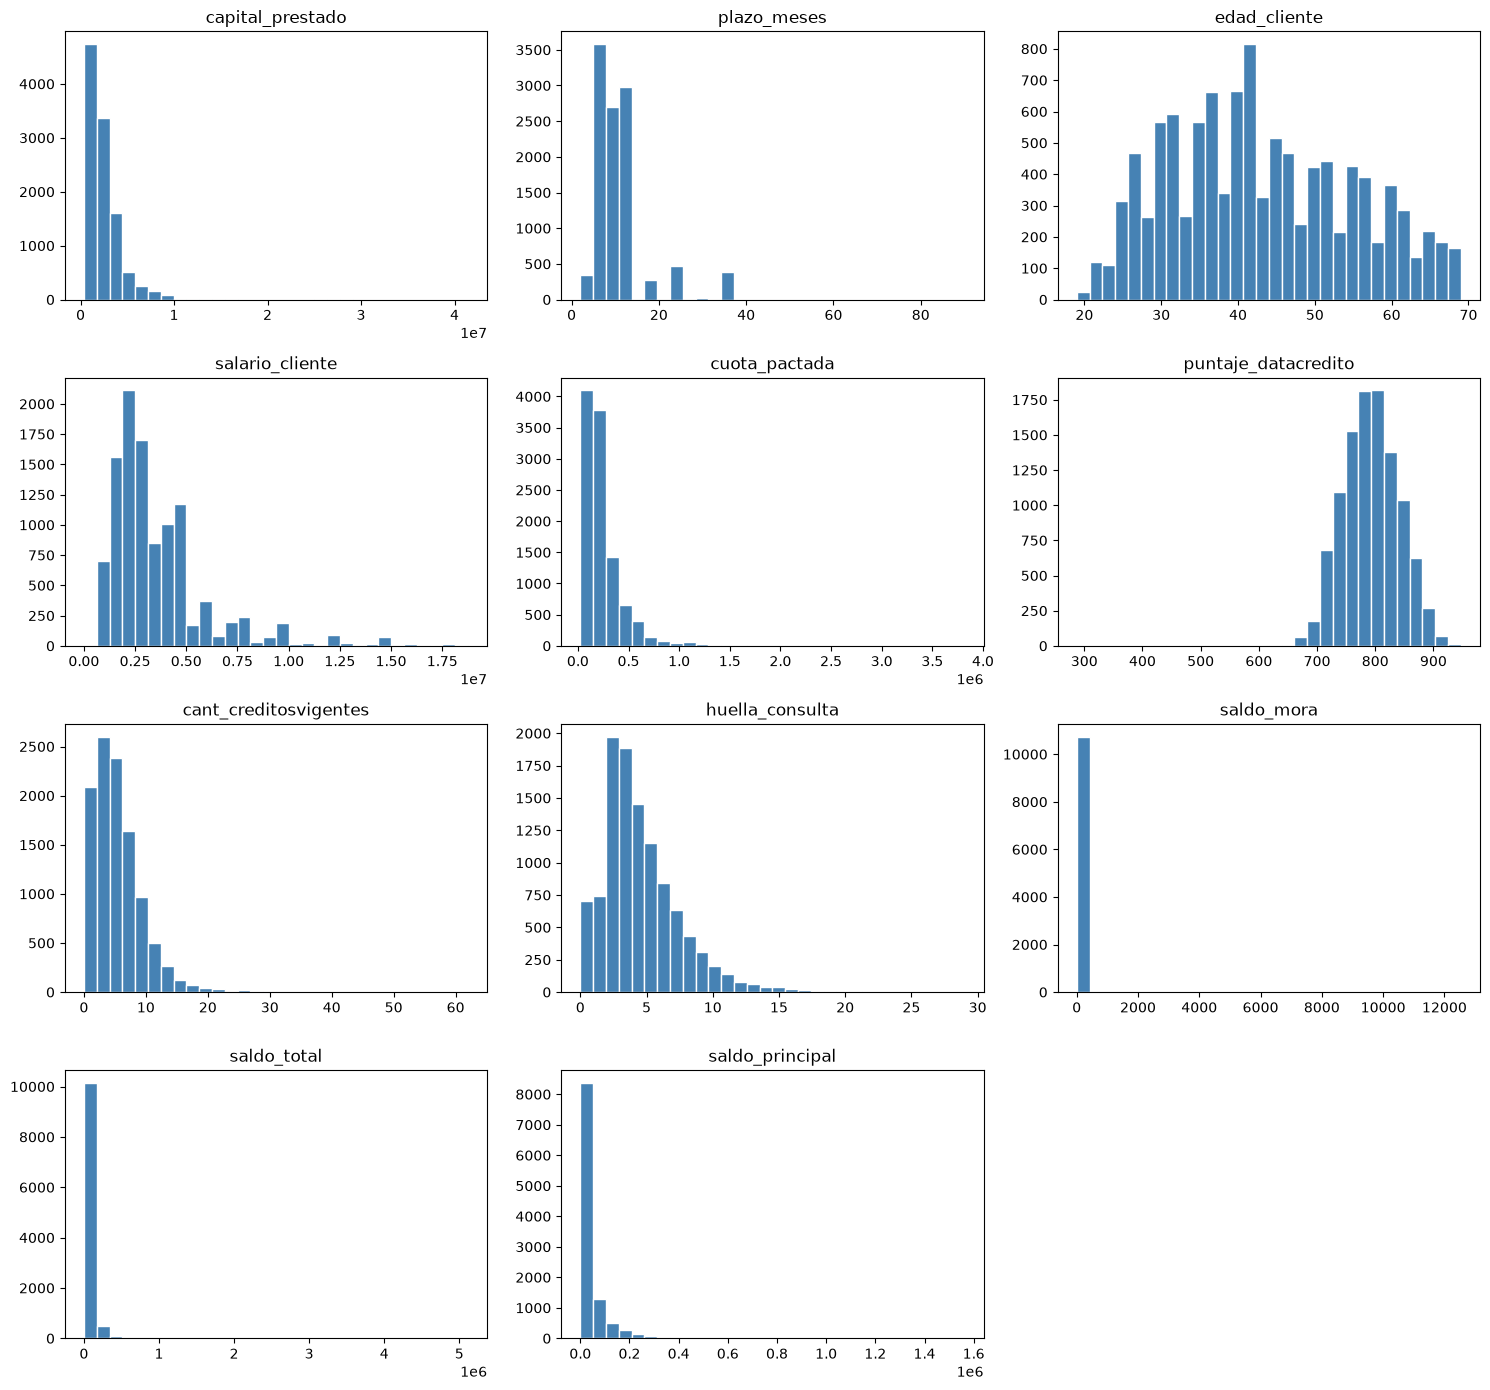

In [21]:
# Histogramas de variables numéricas (forma de la distribución)
import matplotlib.pyplot as plt

vars_hist = ['capital_prestado', 'plazo_meses', 'edad_cliente', 'salario_cliente',
             'cuota_pactada', 'puntaje_datacredito', 'cant_creditosvigentes',
             'huella_consulta', 'saldo_mora', 'saldo_total', 'saldo_principal']

fig, axes = plt.subplots(4, 3, figsize=(15, 14))
axes = axes.flatten()
for i, col in enumerate(vars_hist):
    axes[i].hist(df[col].dropna(), bins=30, color='steelblue', edgecolor='white')
    axes[i].set_title(col)
for j in range(len(vars_hist), len(axes)):
    fig.delaxes(axes[j])
plt.tight_layout()
plt.show()

#### Observaciones de los histogramas

**Variables monetarias (`capital_prestado`, `salario_cliente`, `cuota_pactada`)**
Las tres presentan la misma forma: una barra alta en los valores bajos y una cola que se extiende
hacia la derecha. En `capital_prestado`, la mediana es de $1.921.920 mientras la media sube a
$2.434.315; que la media supere a la mediana confirma que unos pocos créditos grandes arrastran
el promedio hacia arriba. Lo mismo ocurre en `salario_cliente` (mediana $3.000.000, media
$3.650.006) y en `cuota_pactada` (mediana $182.863, media $243.617).
*Implicación:* usar la media como "valor típico" en estas variables sería engañoso; debe usarse
la mediana.

**`plazo_meses`**
No es una distribución continua sino escalonada: se concentra en valores comerciales redondos.
Los plazos de 6 meses (3.326 créditos) y 12 meses (2.658) concentran por sí solos el 55,6% de la
cartera, seguidos de 10 meses (1.520). La entidad opera con plazos cortos: el percentil 90 está
en 18 meses.

**`edad_cliente`**
Es la única variable con forma cercana a una campana. Se concentra entre los 30 y los 55 años,
con mediana en 42. No presenta la cola larga de las variables monetarias, lo que coincide con su
asimetría casi nula (skewness 0,27).

**`puntaje_datacredito`**
Tras depurar los 153 valores inválidos, la distribución se concentra entre 700 y 900 puntos
(mediana 792). La barra dominante en la zona alta indica que la mayoría de los clientes
aprobados ya tenían buen score, lo cual es esperable: son créditos que la entidad efectivamente
desembolsó, no solicitudes.

**`cant_creditosvigentes` y `huella_consulta`**
Ambas son conteos con forma de cola descendente. La mediana de créditos vigentes es 5 y la de
consultas 4. El 3,8% de los clientes no tiene ningún crédito vigente y el 6,5% no registra
consultas recientes.

**Los tres saldos (`saldo_mora`, `saldo_total`, `saldo_principal`)**
Aquí el histograma es casi una sola barra pegada al cero. El caso extremo es `saldo_mora`: el
**99,5% de los registros vale exactamente 0**, por lo que el gráfico prácticamente no muestra
variación. `saldo_total` y `saldo_principal` tienen 8,8% y 9,6% de ceros respectivamente.
*Implicación:* para estas variables, el monto aporta poca información; resulta más útil una
variable binaria del tipo "tiene saldo / no tiene saldo", como se propone en la sección de
atributos derivados.

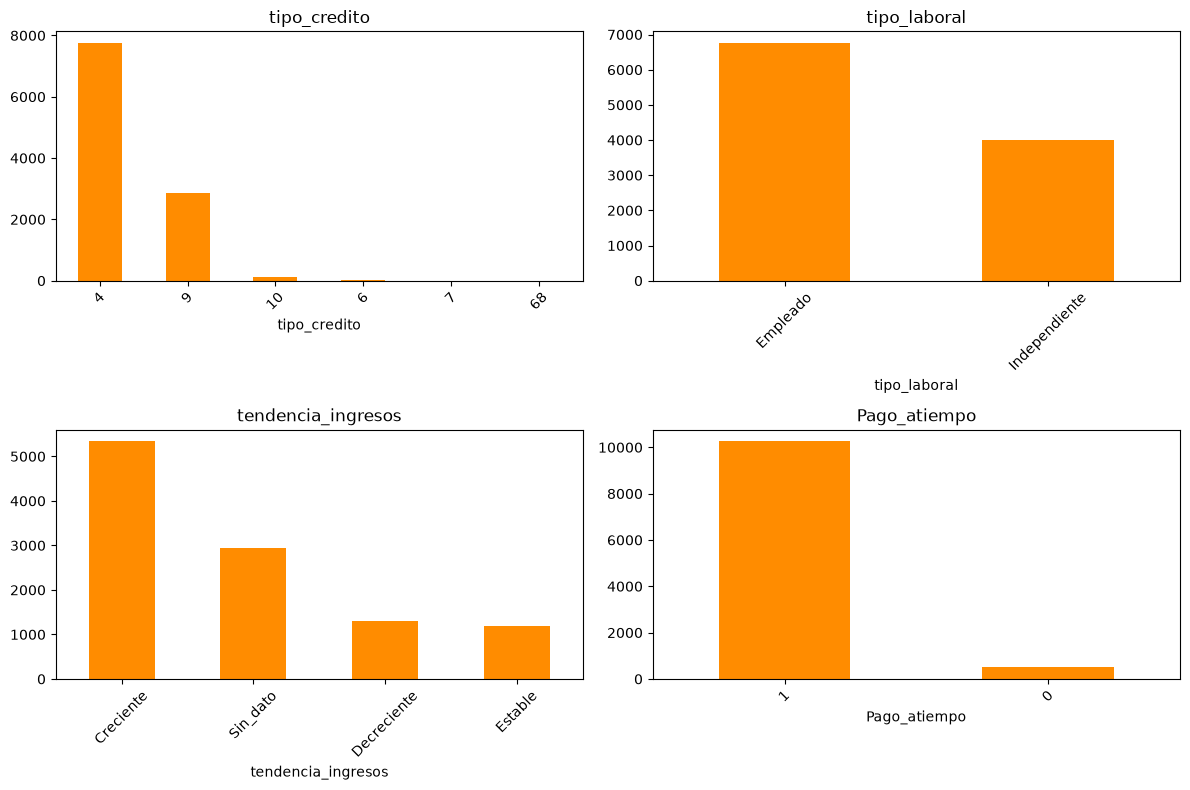


tipo_credito:
tipo_credito
4     7747
9     2876
10     116
6       21
7        2
68       1
Name: count, dtype: int64

tipo_laboral:
tipo_laboral
Empleado         6754
Independiente    4009
Name: count, dtype: int64

tendencia_ingresos:
tendencia_ingresos
Creciente      5335
Sin_dato       2932
Decreciente    1301
Estable        1195
Name: count, dtype: int64

Pago_atiempo:
Pago_atiempo
1    10252
0      511
Name: count, dtype: int64


In [22]:
# Countplots de variables categóricas
vars_cat = ['tipo_credito', 'tipo_laboral', 'tendencia_ingresos', 'Pago_atiempo']

fig, axes = plt.subplots(2, 2, figsize=(12, 8))
axes = axes.flatten()
for i, col in enumerate(vars_cat):
    df[col].value_counts().plot(kind='bar', ax=axes[i], color='darkorange')
    axes[i].set_title(col)
    axes[i].tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

# Verificación
for col in vars_cat:
    print(f"\n{col}:")
    print(df[col].value_counts())

#### Observaciones de los countplots

**`tipo_credito` — concentración extrema**
Dos categorías acaparan casi toda la cartera: el tipo 4 con 7.747 créditos (71,98%) y el tipo 9
con 2.876 (26,72%). Juntos suman el 98,7%. Las demás categorías son marginales: tipo 10 con 116
registros (1,08%), tipo 6 con 21 (0,20%), tipo 7 con 2 y tipo 68 con 1 solo registro.
*Implicación para el análisis:* cualquier conclusión sobre los tipos 6, 7 y 68 se apoya en muy
pocos casos y debe presentarse como indicio, no como resultado concluyente. Para la fase de
modelado convendrá agrupar las categorías minoritarias en una sola clase "Otros".

**`tipo_laboral` — reparto desigual pero utilizable**
6.754 empleados (62,75%) frente a 4.009 independientes (37,25%). Ambos grupos tienen tamaño
suficiente para comparar tasas de mora con confianza, a diferencia de lo que ocurre con
`tipo_credito`.

**`tendencia_ingresos` — la segunda barra es un dato faltante**
`Creciente` domina con 5.335 registros (49,57%), pero la segunda categoría más frecuente es
`Sin_dato` con 2.932 (27,24%). Es decir, **más de una cuarta parte de la cartera no tiene esta
información**. `Decreciente` (1.301) y `Estable` (1.195) quedan por debajo del 13% cada una.
*Observación importante:* que `Sin_dato` sea tan frecuente obliga a tratarla como una categoría
con significado propio y no como un hueco a rellenar.

**`Pago_atiempo` — el desbalance visto de frente**
La diferencia visual entre las dos barras es la constatación gráfica del problema central del
proyecto: 10.252 créditos al día (95,25%) contra 511 en mora (4,75%). La barra de mora es tan
pequeña que apenas se aprecia junto a la otra.

### Interpretación — Tipo de distribución (3.1)

Con base en el `describe()`, las medidas de dispersión y los histogramas:

| Variable | Skewness | Kurtosis | Distribución observada |
|---|---|---|---|
| `edad_cliente` | 0.27 | -0.83 | Aproximadamente **simétrica / cuasi-gaussiana**; ligeramente sesgada a la derecha y algo más plana que una normal |
| `capital_prestado` | 3.72 | 35.3 | **Fuertemente sesgada a la derecha** (log-normal) |
| `salario_cliente` | 2.20 | 6.34 | **Sesgada a la derecha** (log-normal) |
| `cuota_pactada` | 3.79 | 26.6 | **Fuertemente sesgada a la derecha** |
| `plazo_meses` | 2.46 | 7.78 | **Sesgada a la derecha**, discreta con concentración en plazos cortos |
| `puntaje_datacredito` | -5.65 | 39.4 | **Sesgada a la izquierda** y **bimodal**: un grupo pequeño con valores cercanos a 0 y el grueso concentrado entre 700 y 999 |
| `cant_creditosvigentes`, `huella_consulta` | 1.80 / 1.49 | 8.62 / 4.00 | Sesgadas a la derecha, tipo conteo (Poisson-like) |
| `saldo_mora`, `saldo_total`, `saldo_principal`, `saldo_mora_codeudor`, `total_otros_prestamos` | 5 a 97 | 52 a 9.813 | **Extremadamente sesgadas a la derecha**: la gran mayoría en 0 y unos pocos valores muy altos |

**Implicaciones para el modelado:**
- Ninguna variable monetaria es gaussiana: si se usan modelos que asumen normalidad o son sensibles a escala, conviene transformación logarítmica o escalado robusto.
- La kurtosis extrema en los saldos indica presencia de valores atípicos legítimos (no errores), propios del negocio financiero.
- `puntaje_datacredito` merece atención: su bimodalidad sugiere dos poblaciones distintas (posiblemente clientes con y sin historial suficiente en la central de riesgo).

## 3.2 Análisis bivariado

In [23]:
# analisis vibariado variables vs pago_atiempo
# Comparación de variables numéricas clave entre clientes al día vs en mora
variables_clave = ['edad_cliente', 'salario_cliente', 'capital_prestado', 
                    'plazo_meses', 'cuota_pactada', 'cant_creditosvigentes', 
                    'huella_consulta', 'puntaje_datacredito']

comparacion = df.groupby('Pago_atiempo')[variables_clave].median()
print("Mediana por grupo (0 = mora, 1 = al día):")
print(comparacion)

Mediana por grupo (0 = mora, 1 = al día):
              edad_cliente  salario_cliente  capital_prestado  plazo_meses  \
Pago_atiempo                                                                 
0                     38.0        3000000.0         2268000.0         10.0   
1                     42.0        3000000.0         1908446.5         10.0   

              cuota_pactada  cant_creditosvigentes  huella_consulta  \
Pago_atiempo                                                          
0                  199002.0                    5.0              5.0   
1                  182576.0                    5.0              4.0   

              puntaje_datacredito  
Pago_atiempo                       
0                           769.0  
1                           792.0  


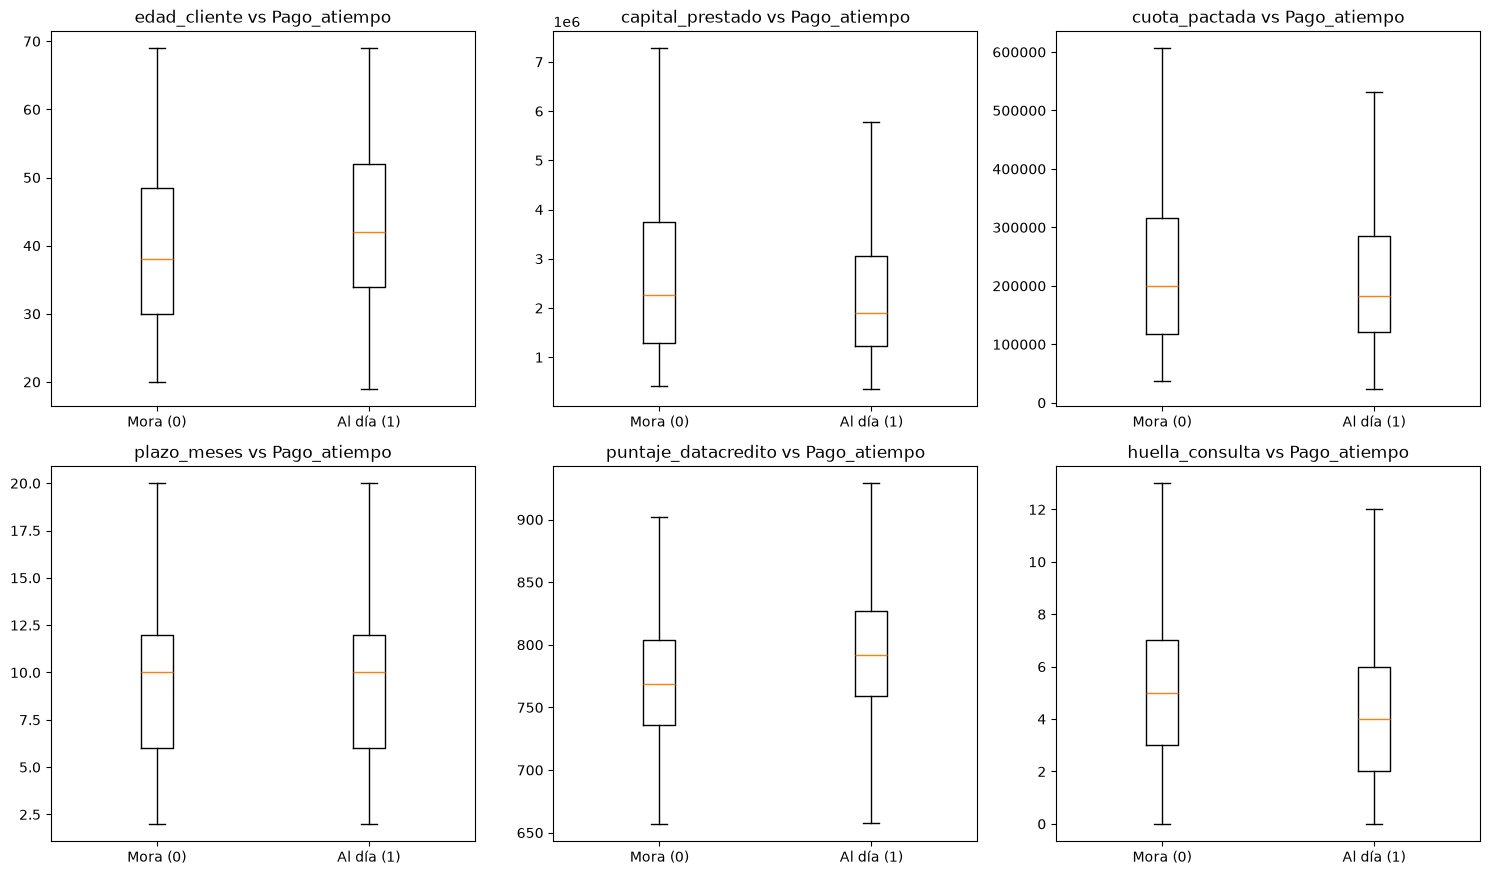

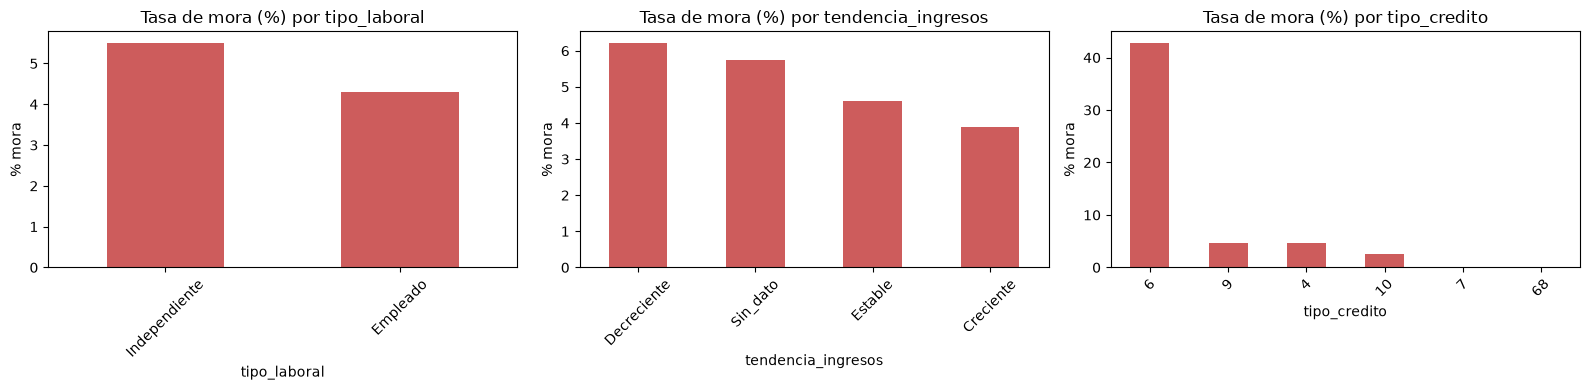

In [24]:
# Gráficos bivariados: distribución de variables clave según la variable objetivo
vars_biv = ['edad_cliente', 'capital_prestado', 'cuota_pactada', 'plazo_meses',
            'puntaje_datacredito', 'huella_consulta']

fig, axes = plt.subplots(2, 3, figsize=(15, 9))
axes = axes.flatten()
for i, col in enumerate(vars_biv):
    datos = [df.loc[df['Pago_atiempo'] == 0, col].dropna(),
             df.loc[df['Pago_atiempo'] == 1, col].dropna()]
    axes[i].boxplot(datos, tick_labels=['Mora (0)', 'Al día (1)'], showfliers=False)
    axes[i].set_title(f'{col} vs Pago_atiempo')
plt.tight_layout()
plt.show()

# Tasa de mora por categoría (gráfico de barras)
fig, axes = plt.subplots(1, 3, figsize=(16, 4))
for ax, col in zip(axes, ['tipo_laboral', 'tendencia_ingresos', 'tipo_credito']):
    tasa = (1 - df.groupby(col)['Pago_atiempo'].mean()) * 100
    tasa.sort_values(ascending=False).plot(kind='bar', ax=ax, color='indianred')
    ax.set_title(f'Tasa de mora (%) por {col}')
    ax.set_ylabel('% mora')
    ax.tick_params(axis='x', rotation=45)
plt.tight_layout()
plt.show()

#### Observaciones de los gráficos bivariados

**Primer gráfico — boxplots por grupo (mora vs. al día)**

Cada par de cajas compara la distribución de una variable entre los créditos que cayeron en mora
(izquierda) y los que se pagaron a tiempo (derecha). Las medianas observadas:

| Variable | En mora | Al día | Diferencia |
|---|---|---|---|
| `edad_cliente` | 38 años | 42 años | Los clientes en mora son 4 años más jóvenes |
| `capital_prestado` | $2.268.000 | $1.908.447 | Pidieron $359.554 más (19% más) |
| `cuota_pactada` | $199.002 | $182.576 | Cuota $16.426 más alta (9% más) |
| `puntaje_datacredito` | 769 | 792 | 23 puntos menos de score |
| `huella_consulta` | 5 consultas | 4 consultas | Una consulta más en la central de riesgo |
| `plazo_meses` | 10 meses | 10 meses | Sin diferencia |

**Lo importante no son las diferencias, sino su tamaño.** Todas apuntan en la dirección esperable
por lógica de negocio, pero son diferencias moderadas y **las cajas se superponen ampliamente en
todos los casos**. Una superposición así significa que existen muchos clientes al día con perfil
similar al de los que cayeron en mora. Ninguna de estas variables, por sí sola, permite trazar
una línea de corte que separe los dos grupos.

**Segundo gráfico — tasas de mora por categoría**

A diferencia de los boxplots, aquí sí aparecen contrastes marcados:

- **`tipo_credito`**: la barra del tipo 6 (42,86%) se dispara respecto a las demás, que se mueven
  entre 2,59% y 4,73%. Es la diferencia más grande de todo el análisis. Con 21 registros, debe
  leerse como señal de alerta, no como conclusión estadística.
- **`tendencia_ingresos`**: existe un orden coherente con el negocio. `Decreciente` presenta la
  mayor tasa (6,23%), seguida de `Sin_dato` (5,73%), luego `Estable` (4,60%) y por último
  `Creciente` (3,88%). Que los clientes con ingresos en descenso incumplan más que los de
  ingresos crecientes es consistente. **Observación destacable:** el grupo `Sin_dato` se ubica en
  el segundo lugar de riesgo, reforzando el hallazgo de que la ausencia de información también es
  informativa.
- **`tipo_laboral`**: los independientes muestran 5,51% frente al 4,29% de los empleados. Es una
  diferencia real pero modesta, de 1,22 puntos porcentuales.

**Nota de lectura:** estas barras son **tasas de mora dentro de cada grupo**, no porciones de un
total. Por eso no suman 100%: cada barra responde a la pregunta "de los clientes de esta
categoría, ¿qué porcentaje cayó en mora?", y cada categoría se calcula por separado.

In [25]:
# tasa de morosidad por segmento categorico
tasa_laboral = df.groupby('tipo_laboral')['Pago_atiempo'].agg(['mean', 'count'])
tasa_laboral['tasa_mora_%'] = ((1 - tasa_laboral['mean']) * 100).round(2)
print(tasa_laboral[['count', 'tasa_mora_%']])

# Tasa de mora por tipo de crédito
tasa_credito = df.groupby('tipo_credito')['Pago_atiempo'].agg(['mean', 'count'])
tasa_credito['tasa_mora_%'] = ((1 - tasa_credito['mean']) * 100).round(2)
print(tasa_credito[['count', 'tasa_mora_%']].sort_values('tasa_mora_%', ascending=False))

               count  tasa_mora_%
tipo_laboral                     
Empleado        6754         4.29
Independiente   4009         5.51
              count  tasa_mora_%
tipo_credito                    
6                21        42.86
9              2876         4.73
4              7747         4.69
10              116         2.59
7                 2         0.00
68                1         0.00


In [26]:
# Bivariado CATEGÓRICA vs CATEGÓRICA: tablas de contingencia y prueba chi-cuadrado.
# Es la prueba estadísticamente correcta para 'tipo_credito' vs la variable objetivo
# (la correlación de Pearson NO aplica sobre variables nominales).
from scipy.stats import chi2_contingency

print("=== Prueba chi-cuadrado de independencia frente a la variable objetivo ===\n")
for col in [c for c in VARS_CATEGORICAS if c in df.columns and c != TARGET]:
    tabla = pd.crosstab(df[col], df[TARGET])
    chi2, p, gl, _ = chi2_contingency(tabla)
    # V de Cramér: tamaño del efecto para variables nominales
    n = tabla.values.sum()
    v_cramer = (chi2 / (n * (min(tabla.shape) - 1))) ** 0.5
    signif = "SÍ" if p < 0.05 else "no"
    print(f"{col}:")
    print(f"   chi2 = {chi2:.2f} | gl = {gl} | p-valor = {p:.4g} | V de Cramér = {v_cramer:.4f}")
    print(f"   ¿Asociación estadísticamente significativa (alfa=0.05)? {signif}\n")

print("=== Tabla de contingencia: tipo_credito vs Pago_atiempo ===")
cont = pd.crosstab(df['tipo_credito'], df[TARGET], margins=True, margins_name='Total')
cont.columns = ['Mora (0)', 'Al día (1)', 'Total']
cont['tasa_mora_%'] = (cont['Mora (0)'] / cont['Total'] * 100).round(2)
print(cont)

=== Prueba chi-cuadrado de independencia frente a la variable objetivo ===

tipo_credito:
   chi2 = 68.86 | gl = 5 | p-valor = 1.772e-13 | V de Cramér = 0.0800
   ¿Asociación estadísticamente significativa (alfa=0.05)? SÍ

tipo_laboral:
   chi2 = 8.00 | gl = 1 | p-valor = 0.004686 | V de Cramér = 0.0273
   ¿Asociación estadísticamente significativa (alfa=0.05)? SÍ

tendencia_ingresos:
   chi2 = 21.48 | gl = 3 | p-valor = 8.375e-05 | V de Cramér = 0.0447
   ¿Asociación estadísticamente significativa (alfa=0.05)? SÍ

=== Tabla de contingencia: tipo_credito vs Pago_atiempo ===
              Mora (0)  Al día (1)  Total  tasa_mora_%
tipo_credito                                          
4                  363        7384   7747         4.69
6                    9          12     21        42.86
7                    0           2      2         0.00
9                  136        2740   2876         4.73
10                   3         113    116         2.59
68                   0           1

**Por qué esta prueba y no una correlación:** `tipo_credito` es una variable nominal. Aplicarle
correlación de Pearson produce r = 0.001, un valor que sugiere ausencia total de relación con la
mora. La prueba chi-cuadrado, que sí es apropiada para variables nominales, revela lo contrario:
existe asociación estadísticamente significativa. La tasa de mora va de 2.59% (tipo 10) a 42.86%
(tipo 6).

Este es el ejemplo más claro de por qué el diccionario de datos importa: **una variable con señal
real quedaba invisible por aplicarle la técnica estadística equivocada.**

## Hallazgos  Segmentación categórica

- **tipo_laboral**: los independientes tienen una tasa de mora ligeramente mayor que los empleados (5.51% vs 4.29%), consistente con mayor variabilidad de ingresos.
- **tipo_credito**: el tipo de crédito **6** muestra una tasa de mora de **42.86%**, muy por encima del resto (~4-5%). Con solo 21 registros, la muestra es pequeña y se necesita más data  qué represente este tipo de crédito para sacar conclusiones como tal definitivas, pero es una señal de alerta fuerte a
- Los tipos 7 y 68 muestran 0% de mora, pero con 1-2 registros cada uno — no son representativos, se excluyen de conclusiones.

## 3.3 Análisis multivariado

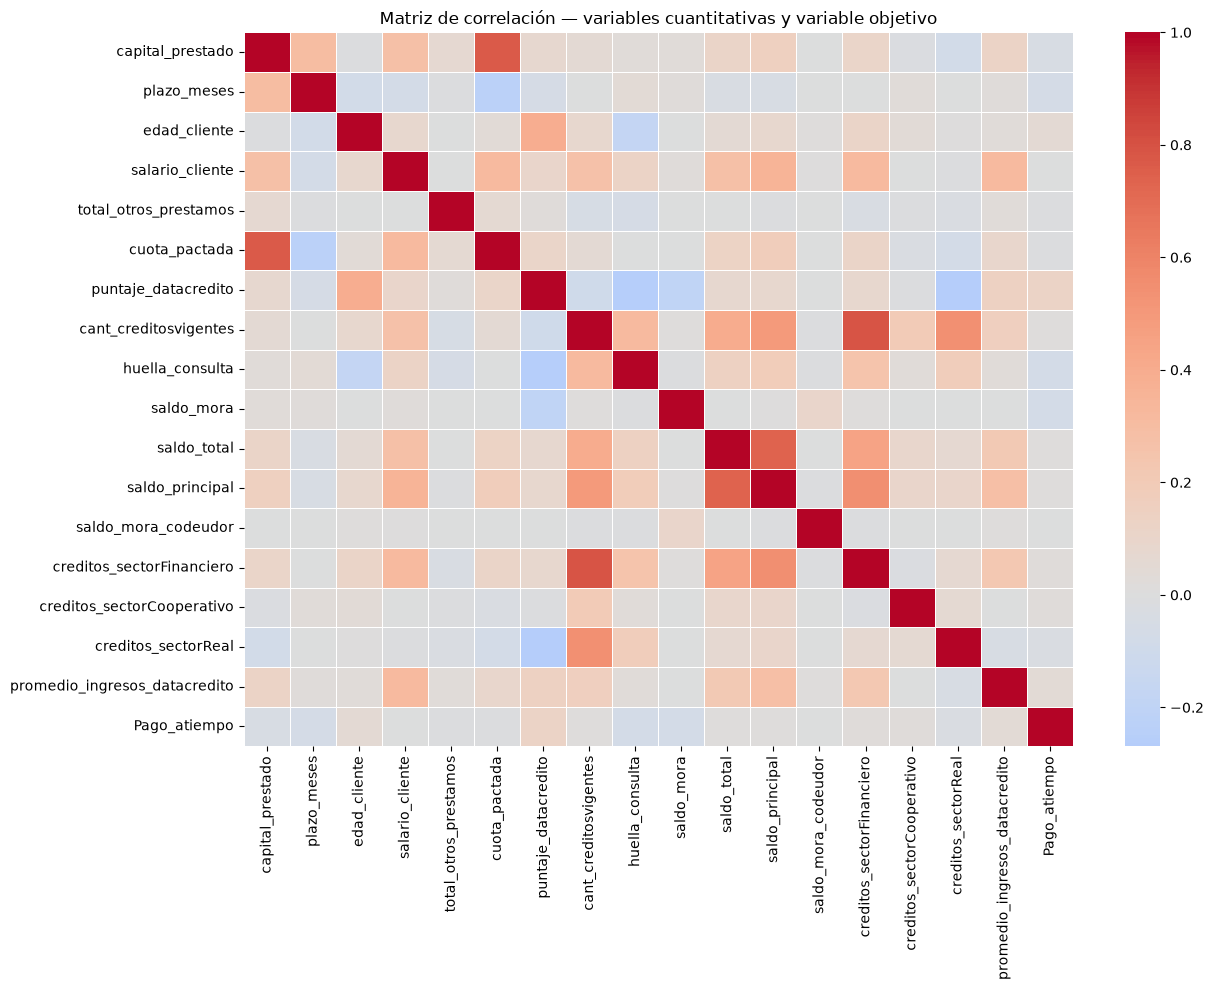

=== Correlación con la variable objetivo, ordenada por magnitud ===
puntaje_datacredito              0.1212
huella_consulta                  0.0737
saldo_mora                       0.0726
plazo_meses                      0.0631
edad_cliente                     0.0524
capital_prestado                 0.0406
promedio_ingresos_datacredito    0.0399
creditos_sectorReal              0.0233
creditos_sectorFinanciero        0.0214
creditos_sectorCooperativo       0.0213
saldo_total                      0.0149
saldo_principal                  0.0135
cuota_pactada                    0.0118
total_otros_prestamos            0.0100
cant_creditosvigentes            0.0088
salario_cliente                  0.0049
saldo_mora_codeudor              0.0026
Name: Pago_atiempo, dtype: float64

=== Pares de variables con multicolinealidad alta (|r| > 0.7) ===
  capital_prestado <-> cuota_pactada: r = 0.764
  cant_creditosvigentes <-> creditos_sectorFinanciero: r = 0.791
  saldo_total <-> saldo_principal: r 

In [27]:
# Matriz de correlación SOLO sobre variables cuantitativas reales.
# 'tipo_credito' queda excluida: la correlación de Pearson sobre un código nominal
# arroja r = 0.001 y OCULTA que ese producto va de 2.6% a 42.9% de tasa de mora
# según la categoría (ver análisis bivariado categórico, sección 3.2).
import seaborn as sns

num_corr = [c for c in VARS_NUMERICAS if c in df.columns] + [TARGET]

corr = df[num_corr].corr()

plt.figure(figsize=(13, 10))
sns.heatmap(corr, cmap='coolwarm', center=0, annot=False, linewidths=0.4)
plt.title('Matriz de correlación — variables cuantitativas y variable objetivo')
plt.tight_layout()
plt.show()

print("=== Correlación con la variable objetivo, ordenada por magnitud ===")
print(corr[TARGET].drop(TARGET).abs().sort_values(ascending=False).round(4))

print("\n=== Pares de variables con multicolinealidad alta (|r| > 0.7) ===")
alta = (corr.abs() > 0.7) & (corr.abs() < 1.0)
pares = set()
for a in corr.columns:
    for b in corr.columns:
        if alta.loc[a, b] and (b, a) not in pares:
            pares.add((a, b))
            print(f"  {a} <-> {b}: r = {corr.loc[a, b]:.3f}")
if not pares:
    print("  Ninguno.")

#### Observaciones de la matriz de correlación

**Cómo leer este gráfico:** cada celda muestra el coeficiente de correlación de Pearson entre dos
variables, en un rango de −1 a +1. Los tonos rojos indican correlación positiva (las dos
variables suben juntas), los azules correlación negativa, y los tonos pálidos ausencia de
relación lineal. La diagonal siempre vale 1 porque es la correlación de cada variable consigo
misma.

**1. Frente a la variable objetivo, todo el panel está pálido.**
La fila de `Pago_atiempo` no muestra ninguna celda intensa. El valor más alto es
`puntaje_datacredito` con |r| = 0,1212, y el resto queda por debajo de 0,075. En una escala de 0
a 1, son correlaciones muy débiles. Esto no significa que las variables sean inútiles: significa
que **ninguna se relaciona con la mora de forma lineal y directa por sí sola**.

**2. Sí aparecen bloques intensos entre variables predictoras.** Se detectaron tres pares con
|r| > 0,7:

| Par de variables | r | Explicación |
|---|---|---|
| `cant_creditosvigentes` ↔ `creditos_sectorFinanciero` | +0,791 | El sector financiero concentra la mayoría de los créditos del cliente, así que ambos conteos crecen juntos |
| `capital_prestado` ↔ `cuota_pactada` | +0,764 | Relación mecánica: a mayor monto prestado, mayor cuota mensual |
| `saldo_total` ↔ `saldo_principal` | +0,737 | El saldo principal es un componente del saldo total |

**3. Las tres son redundancias esperables, no errores.** En los tres casos una variable contiene
parte de la información de la otra por construcción.
*Implicación para la fase de modelado:* incluir variables tan correlacionadas en un modelo lineal
distorsiona los coeficientes y dificulta explicar el peso real de cada factor, algo crítico en
riesgo crediticio donde hay que justificar la negación de un crédito. Convendrá conservar una de
cada par o emplear un modelo robusto a la multicolinealidad.

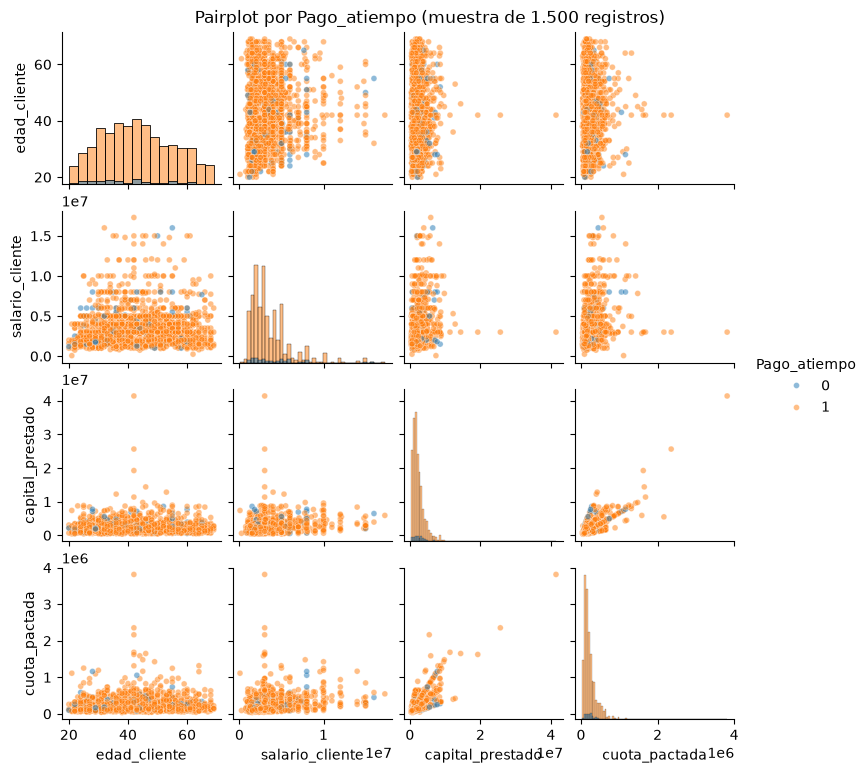

In [28]:
# Pairplot de un subconjunto de variables, coloreado por la variable objetivo (hue)
sub = ['edad_cliente', 'salario_cliente', 'capital_prestado', 'cuota_pactada', 'Pago_atiempo']
muestra = df[sub].dropna().sample(n=min(1500, len(df)), random_state=42)

sns.pairplot(muestra, hue='Pago_atiempo', diag_kind='hist',
             plot_kws={'alpha': 0.5, 's': 18}, height=1.9)
plt.suptitle('Pairplot por Pago_atiempo (muestra de 1.500 registros)', y=1.01)
plt.show()

#### Observaciones del pairplot

**Qué muestra:** cada casilla fuera de la diagonal cruza dos variables; los puntos azules son
créditos pagados a tiempo y los rojos créditos en mora. La diagonal muestra el histograma de cada
variable separado por clase.

**1. Los puntos rojos no forman ningún grupo propio.** En las cuatro variables cruzadas
(`edad_cliente`, `salario_cliente`, `capital_prestado`, `cuota_pactada`) los casos de mora
aparecen repartidos dentro de la misma nube que los créditos al día. No existe ninguna región del
gráfico que se pueda señalar diciendo "aquí se concentra la mora".

**2. La escasez de puntos rojos es visualmente evidente.** Con solo 4,75% de casos de mora, y
usando una muestra de 1.500 registros, aparecen alrededor de 70 puntos rojos frente a más de
1.400 azules. Esta desproporción visual es la misma que enfrentará un modelo al entrenar.

**3. La única estructura clara no involucra a la variable objetivo.** El cruce
`capital_prestado` × `cuota_pactada` dibuja una línea ascendente definida, que corresponde a la
correlación de 0,764 ya detectada. Es una relación entre predictores, no una señal de riesgo.

**4. Los histogramas de la diagonal se superponen.** Para cada variable, la distribución de los
clientes en mora se solapa casi por completo con la de los clientes al día. Si alguna variable
separara bien las clases, veríamos dos curvas desplazadas una respecto de la otra.

**Conclusión del pairplot:** no existe un par de variables que permita construir una regla de
decisión simple del tipo "si el capital supera X y la edad es menor que Y, entonces hay riesgo".
Esto respalda la decisión de recurrir a un modelo multivariado en la Fase 3 en lugar de reglas de
negocio manuales.

In [29]:
# Tablas cruzadas: relación entre variables categóricas y la variable objetivo
print("=== tipo_laboral x tendencia_ingresos: tasa de mora (%) ===")
tabla = df.pivot_table(index='tipo_laboral', columns='tendencia_ingresos',
                       values='Pago_atiempo', aggfunc='mean')
print(((1 - tabla) * 100).round(2))

print("\n=== Conteo de registros por combinación ===")
print(pd.crosstab(df['tipo_laboral'], df['tendencia_ingresos']))

=== tipo_laboral x tendencia_ingresos: tasa de mora (%) ===
tendencia_ingresos  Creciente  Decreciente  Estable  Sin_dato
tipo_laboral                                                 
Empleado                 3.54         5.81     4.46      5.37
Independiente            4.78         7.32     4.77      6.01

=== Conteo de registros por combinación ===
tendencia_ingresos  Creciente  Decreciente  Estable  Sin_dato
tipo_laboral                                                 
Empleado                 3872          946      650      1286
Independiente            1463          355      545      1646


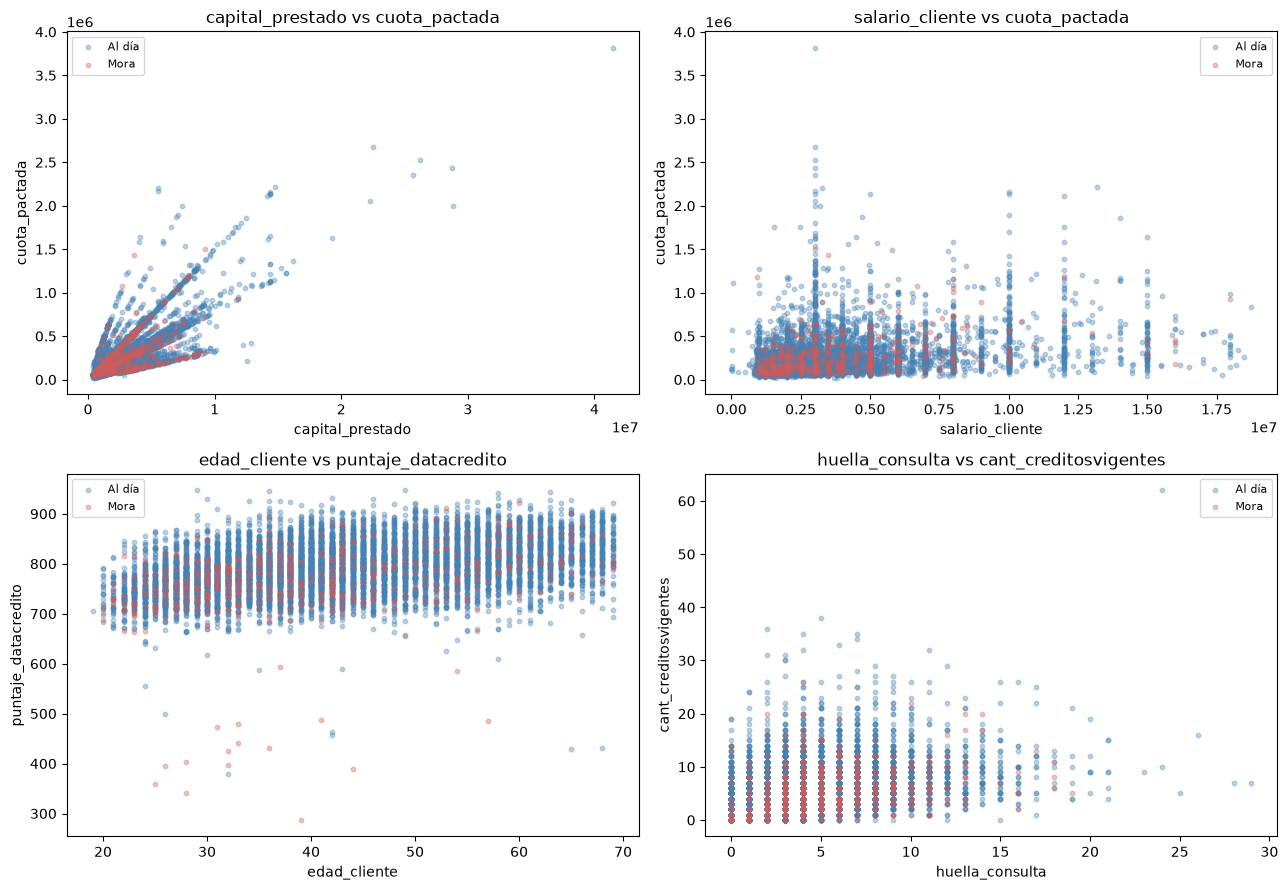

In [30]:
# Gráficos de dispersión entre variables numéricas, coloreados por la variable objetivo (hue).
# Permiten ver simultáneamente la relación entre dos variables y el resultado de pago.
pares = [('capital_prestado', 'cuota_pactada'),
         ('salario_cliente', 'cuota_pactada'),
         ('edad_cliente', 'puntaje_datacredito'),
         ('huella_consulta', 'cant_creditosvigentes')]

fig, axes = plt.subplots(2, 2, figsize=(13, 9))
axes = axes.flatten()
for ax, (x, y) in zip(axes, pares):
    for clase, color, etiqueta in [(1, 'steelblue', 'Al día'), (0, 'indianred', 'Mora')]:
        sub = df[df[TARGET] == clase]
        ax.scatter(sub[x], sub[y], s=10, alpha=0.35, c=color, label=etiqueta)
    ax.set_xlabel(x); ax.set_ylabel(y)
    ax.set_title(f'{x} vs {y}')
    ax.legend(fontsize=8)
plt.tight_layout()
plt.show()

#### Observaciones de los gráficos de dispersión

- **`capital_prestado` vs `cuota_pactada`**: relación lineal clara y esperable (r = 0.764) —
  a mayor capital, mayor cuota. Es la multicolinealidad detectada en la matriz de correlación.
- **`salario_cliente` vs `cuota_pactada`**: la nube es difusa. No existe una regla evidente que
  ligue el ingreso declarado con la cuota asignada, lo que explica que el ratio cuota/ingreso
  resultara poco informativo.
- **`edad_cliente` vs `puntaje_datacredito`**: se observa mayor dispersión de scores bajos entre
  los clientes más jóvenes.
- **`huella_consulta` vs `cant_creditosvigentes`**: los casos de mora (rojo) se concentran
  visiblemente en la zona de muchas consultas con pocos créditos vigentes — coherente con la
  idea de búsqueda intensa de financiación.

En los cuatro gráficos, **los puntos rojos se mezclan con los azules**: ninguna combinación de
dos variables separa limpiamente a los clientes en mora, lo que refuerza que el riesgo depende
de múltiples factores simultáneos.

### Hallazgos — Análisis multivariado (3.3)

- **Correlaciones con la variable objetivo muy débiles**: tras depurar los scores inválidos,
  `puntaje_datacredito` alcanza |r| = 0.1212 y se convierte en el predictor cuantitativo más
  fuerte. Le siguen `huella_consulta` (0.074), `saldo_mora` (0.073) y `plazo_meses` (0.063).
  Ninguna otra variable supera |r| = 0.08.
- **Multicolinealidad detectada**: `capital_prestado` y `cuota_pactada` presentan r = 0.764,
  relación esperable por construcción. Debe considerarse al elegir el modelo, ya que afecta la
  interpretabilidad de los coeficientes en modelos lineales.
- **Redundancia entre saldos y conteos por sector**: `saldo_total`, `saldo_principal` y
  `saldo_mora` se relacionan entre sí por construcción, al igual que los créditos por sector
  respecto a `cant_creditosvigentes`.
- **Sin separabilidad visual entre clases**: ni el pairplot ni los gráficos de dispersión
  muestran fronteras claras entre clientes al día y en mora. Las nubes de puntos se superponen
  ampliamente, reflejando tanto el fuerte desbalance (4.75% de mora) como la ausencia de
  separabilidad lineal simple.
- **Interacción entre categóricas**: las tablas cruzadas entre `tipo_laboral` y
  `tendencia_ingresos` permiten observar si el riesgo del segmento independiente se concentra
  en algún patrón de ingresos específico.

# 4. Reglas de validación de datos

In [31]:
# Reglas de validación derivadas del DICCIONARIO DE DATOS y de fuentes oficiales.
# Reutilizables en etapas posteriores del pipeline (ft_engineering.py, model_deploy.py)
# y para validar datos nuevos en producción.
#
# CORRECCIÓN APLICADA: el rango de 'puntaje_datacredito' era [0, 1000], un rango
# inventado sin fuente. El rango oficial de DataCrédito Experian es [150, 950].
# La regla anterior detectaba 1 solo registro inválido; la corregida detecta 153.

REGLAS_VALIDACION = {
    'edad_cliente':          {'min': 18,   'max': 90,         'nulos_permitidos': False,
                              'fuente': 'Mayoría de edad legal + brecha observada en la distribución (70-120)'},
    'salario_cliente':       {'min': 1,    'max': 20_000_000, 'nulos_permitidos': False,
                              'fuente': 'Límite IQR sobre escala logarítmica (~18.79M), redondeado'},
    'capital_prestado':      {'min': 1,    'max': 50_000_000, 'nulos_permitidos': False,
                              'fuente': 'Máximo observado 41.4M + margen'},
    'plazo_meses':           {'min': 1,    'max': 120,        'nulos_permitidos': False,
                              'fuente': 'Máximo observado 90 meses + margen comercial'},
    'cuota_pactada':         {'min': 1,    'max': 5_000_000,  'nulos_permitidos': False,
                              'fuente': 'Rango observado'},
    'puntaje_datacredito':   {'min': 150,  'max': 950,        'nulos_permitidos': True,
                              'fuente': 'Rango oficial DataCrédito Experian (Términos y Condiciones Midatacrédito). '
                                        'Nulos permitidos: representan ausencia de historial (ver sección 2.4)'},
    'cant_creditosvigentes': {'min': 0,    'max': 100,        'nulos_permitidos': False,
                              'fuente': 'Máximo observado 62 + margen'},
    'huella_consulta':       {'min': 0,    'max': 50,         'nulos_permitidos': False,
                              'fuente': 'Máximo observado 30 + margen'},
    'saldo_mora':            {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'saldo_total':           {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'saldo_principal':       {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'saldo_mora_codeudor':   {'min': 0,    'max': None,       'nulos_permitidos': False,
                              'fuente': 'Un saldo no puede ser negativo'},
    'tipo_credito':          {'valores': [4, 6, 7, 9, 10, 68], 'nulos_permitidos': False,
                              'fuente': 'Códigos observados en el dataset (significado sin confirmar)'},
    'tipo_laboral':          {'valores': ['Empleado', 'Independiente'], 'nulos_permitidos': False,
                              'fuente': 'Dominio cerrado observado'},
    'tendencia_ingresos':    {'valores': ['Creciente', 'Decreciente', 'Estable', 'Sin_dato'],
                              'nulos_permitidos': False,
                              'fuente': 'Dominio cerrado tras reconstrucción (sección 2.4)'},
    'Pago_atiempo':          {'valores': [0, 1], 'nulos_permitidos': False,
                              'fuente': 'Variable objetivo binaria'},
}


def validar_dataframe(datos, reglas=REGLAS_VALIDACION):
    """Valida un DataFrame contra las reglas definidas. Devuelve lista de violaciones."""
    violaciones = []
    for col, regla in reglas.items():
        if col not in datos.columns:
            violaciones.append(f"{col}: columna ausente")
            continue
        if not regla.get('nulos_permitidos', True) and datos[col].isnull().any():
            violaciones.append(f"{col}: {datos[col].isnull().sum()} nulos no permitidos")
        serie = datos[col].dropna()
        if 'valores' in regla:
            invalidos = ~serie.isin(regla['valores'])
            if invalidos.any():
                violaciones.append(f"{col}: {invalidos.sum()} valores fuera del dominio permitido")
        else:
            if regla.get('min') is not None and (serie < regla['min']).any():
                violaciones.append(f"{col}: {(serie < regla['min']).sum()} valores bajo el mínimo ({regla['min']})")
            if regla.get('max') is not None and (serie > regla['max']).any():
                violaciones.append(f"{col}: {(serie > regla['max']).sum()} valores sobre el máximo ({regla['max']})")
    return violaciones


print("=== Validación del dataset ya limpio ===")
resultado = validar_dataframe(df)
if resultado:
    for v in resultado:
        print(" -", v)
else:
    print("Sin violaciones: el dataset cumple todas las reglas definidas.")

print("\n=== Comprobación del impacto de la corrección ===")
crudo = pd.read_csv('../Base_de_datos.csv', sep=';', encoding='utf-8-sig')
regla_anterior = ((crudo['puntaje_datacredito'] < 0) | (crudo['puntaje_datacredito'] > 1000)).sum()
regla_corregida = ((crudo['puntaje_datacredito'] < 150) | (crudo['puntaje_datacredito'] > 950)).sum()
print(f"Registros inválidos detectados con la regla anterior [0, 1000]: {regla_anterior}")
print(f"Registros inválidos detectados con la regla corregida [150, 950]: {regla_corregida}")
print(f"Registros que pasaban silenciosamente: {regla_corregida - regla_anterior}")

=== Validación del dataset ya limpio ===
Sin violaciones: el dataset cumple todas las reglas definidas.

=== Comprobación del impacto de la corrección ===
Registros inválidos detectados con la regla anterior [0, 1000]: 1
Registros inválidos detectados con la regla corregida [150, 950]: 153
Registros que pasaban silenciosamente: 152


### Reglas de validación — justificación

Los rangos se derivan del diccionario de datos y de fuentes verificables, no de criterios
arbitrarios. Cada regla lleva su campo `fuente` en el código.

| Variable | Rango | Origen del criterio |
|---|---|---|
| `edad_cliente` | [18, 90] | Mayoría de edad legal; el techo se apoya en la brecha vacía observada entre 70 y 120 años |
| `salario_cliente` | [1, 20.000.000] | Límite IQR sobre escala logarítmica (~$18.79M), redondeado al alza |
| `puntaje_datacredito` | **[150, 950]** | **Rango oficial DataCrédito Experian.** Corrige el rango [0, 1000] usado antes, que no tenía fuente |
| `plazo_meses` | [1, 120] | Máximo observado 90 meses, con margen comercial |
| Dominios categóricos | Listas cerradas | Cualquier valor fuera indica corrupción, como los 58 registros numéricos hallados en `tendencia_ingresos` |

**Impacto medido de la corrección:** la regla anterior `[0, 1000]` detectaba **1** registro
inválido. La regla corregida `[150, 950]` detecta **153** — es decir, **152 registros
inválidos pasaban silenciosamente por la validación**, incluidos los 145 con valor `0` que en
realidad representan ausencia de historial crediticio.

# 5. Identificación del atributo objetivo (target)

In [32]:
# Declaración explícita de la variable objetivo (target)
TARGET = 'Pago_atiempo'

print(f"Variable objetivo: {TARGET}")
print(f"Tipo: categórica binaria (dicotómica)")
print("\nDistribución de clases:")
dist = df[TARGET].value_counts()
dist_pct = df[TARGET].value_counts(normalize=True).mul(100).round(2)
print(pd.DataFrame({'registros': dist, 'porcentaje': dist_pct}))

ratio = dist.max() / dist.min()
print(f"\nRatio de desbalance: {ratio:.1f} a 1")
print(f"Clase minoritaria (mora, 0): {dist.get(0, 0)} registros ({dist_pct.get(0, 0)}%)")

Variable objetivo: Pago_atiempo
Tipo: categórica binaria (dicotómica)

Distribución de clases:
              registros  porcentaje
Pago_atiempo                       
1                 10252       95.25
0                   511        4.75

Ratio de desbalance: 20.1 a 1
Clase minoritaria (mora, 0): 511 registros (4.75%)


### Atributo objetivo 

**`Pago_atiempo`** es la variable objetivo del proyecto: indica si el crédito se pagó a tiempo (1) o cayó en mora (0). Esto define el problema como **clasificación binaria supervisada**, alineado con la pregunta de negocio planteada en el enunciado (evaluar el pago del crédito).

Consideraciones críticas para las fases siguientes:

1. **Fuerte desbalance de clases (~20 a 1)**: solo el 4.75% de los registros corresponde a mora. Un modelo que prediga siempre "paga a tiempo" alcanzaría 95.25% de exactitud sin aprender nada útil. Por lo tanto, **la exactitud (accuracy) no es una métrica válida** aquí; deben usarse precisión, recall, F1 y AUC-PR, priorizando el recall sobre la clase minoritaria (detectar la mora es el objetivo de negocio).
2. **Técnicas de balanceo a evaluar**: `class_weight='balanced'`, submuestreo, o SMOTE — aplicadas únicamente sobre el conjunto de entrenamiento, nunca sobre el de prueba.
3. **Riesgo de fuga de información (data leakage)**: variables como `saldo_mora` y `saldo_mora_codeudor` describen mora ya existente. Debe confirmarse con el negocio si se registran **antes** del desembolso (información válida del historial) o **después** (contaminarían el modelo, ya que serían consecuencia y no causa del impago). Esta validación es imprescindible antes de entrenar.

# 6. Transformaciones futuras aplicables

In [33]:
# Identificación de transformaciones aplicables en la fase de Feature Engineering

transformaciones = [
    ('tipo_laboral',        'One-Hot Encoding',        'Categórica dicotómica nominal; genera 1 columna binaria'),
    ('tendencia_ingresos',  'One-Hot Encoding',        'Categórica politómica (4 niveles, incluye Sin_dato como categoría informativa)'),
    ('tipo_credito',        'One-Hot / agrupación',    'Nominal con 6 niveles muy desbalanceados; agrupar los de baja frecuencia (7, 68, 6) en "Otros"'),
    ('capital_prestado',    'Transformación log',      'Skewness 3.72; log reduce el sesgo y la influencia de valores extremos'),
    ('salario_cliente',     'Transformación log',      'Skewness 2.20; variable monetaria fuertemente asimétrica'),
    ('cuota_pactada',       'Transformación log',      'Skewness 3.79'),
    ('total_otros_prestamos','Transformación log1p',   'Skewness 38.5 y contiene ceros; log1p maneja el cero correctamente'),
    ('saldos (4 columnas)', 'log1p + indicador binario','Alta concentración en cero; el indicador "tiene saldo" puede ser más informativo que el monto'),
    ('variables numéricas', 'Escalado robusto',        'RobustScaler resiste mejor los atípicos que StandardScaler, necesario si se usan modelos sensibles a escala'),
    ('fecha_prestamo',      'Extracción temporal',     'Derivar mes, trimestre y antigüedad del crédito; la fecha cruda no es utilizable como predictor'),
    ('promedio_ingresos_datacredito', 'Imputación + flag', 'Decisión diferida: si el modelo no admite NaN (regresión logística), imputar y conservar el indicador de ausencia'),
]

plan = pd.DataFrame(transformaciones, columns=['Variable', 'Transformación', 'Justificación'])
print(plan.to_string(index=False))

                     Variable            Transformación                                                                                                     Justificación
                 tipo_laboral          One-Hot Encoding                                                           Categórica dicotómica nominal; genera 1 columna binaria
           tendencia_ingresos          One-Hot Encoding                                    Categórica politómica (4 niveles, incluye Sin_dato como categoría informativa)
                 tipo_credito      One-Hot / agrupación                    Nominal con 6 niveles muy desbalanceados; agrupar los de baja frecuencia (7, 68, 6) en "Otros"
             capital_prestado        Transformación log                                            Skewness 3.72; log reduce el sesgo y la influencia de valores extremos
              salario_cliente        Transformación log                                                          Skewness 2.20; variable monetaria fue

# 7. Atributos adicionales (derivados/calculados)

In [34]:
# Atributos derivados propuestos, construidos con lógica de negocio financiero.
# Se calculan aquí para EVALUAR su valor predictivo; su implementación definitiva
# corresponde a la fase de Feature Engineering (ft_engineering.py).

derivadas = df.copy()

# 1. Capacidad de pago: qué porcentaje del ingreso consume la cuota del crédito
derivadas['ratio_cuota_ingreso'] = derivadas['cuota_pactada'] / derivadas['salario_cliente']

# 2. Nivel de endeudamiento previo respecto al ingreso
derivadas['ratio_deuda_ingreso'] = derivadas['total_otros_prestamos'] / derivadas['salario_cliente']

# 3. Magnitud del crédito respecto al ingreso mensual
derivadas['ratio_capital_ingreso'] = derivadas['capital_prestado'] / derivadas['salario_cliente']

# 4. Presencia de mora previa (señal binaria, más robusta que el monto)
derivadas['tiene_mora_previa'] = (derivadas['saldo_mora'] > 0).astype(int)

# 5. Diversificación de crédito: total de créditos across sectores
derivadas['total_creditos_sectores'] = derivadas[['creditos_sectorFinanciero',
                                                  'creditos_sectorCooperativo',
                                                  'creditos_sectorReal']].sum(axis=1)

# 6. Intensidad de búsqueda de crédito: consultas por crédito vigente
derivadas['consultas_por_credito'] = derivadas['huella_consulta'] / (derivadas['cant_creditosvigentes'] + 1)

# 7. Discrepancia entre el ingreso declarado y el reportado en central de riesgo
derivadas['discrepancia_ingresos'] = (
    derivadas['salario_cliente'] - derivadas['promedio_ingresos_datacredito']
) / derivadas['salario_cliente']

# 8. Componentes temporales de la fecha de préstamo
derivadas['mes_prestamo'] = derivadas['fecha_prestamo'].dt.month
derivadas['trimestre_prestamo'] = derivadas['fecha_prestamo'].dt.quarter

nuevas = ['ratio_cuota_ingreso', 'ratio_deuda_ingreso', 'ratio_capital_ingreso',
          'tiene_mora_previa', 'total_creditos_sectores', 'consultas_por_credito',
          'discrepancia_ingresos', 'mes_prestamo', 'trimestre_prestamo']

print("Atributos derivados creados:", len(nuevas))
print(derivadas[nuevas].describe().T)

Atributos derivados creados: 9
                           count      mean        std        min       25%  \
ratio_cuota_ingreso      10763.0  0.098927   1.242397   0.003107  0.040208   
ratio_deuda_ingreso      10763.0  2.250027  45.960172   0.000000  0.213192   
ratio_capital_ingreso    10763.0  0.961538   8.337129   0.040200  0.387905   
tiene_mora_previa        10763.0  0.005110   0.071305   0.000000  0.000000   
total_creditos_sectores  10763.0  4.352504   3.489233   0.000000  2.000000   
consultas_por_credito    10763.0  0.774194   0.723288   0.000000  0.333333   
discrepancia_ingresos     7833.0  0.353508   0.554426 -18.053290  0.070140   
mes_prestamo             10763.0  5.274087   3.717484   1.000000  2.000000   
trimestre_prestamo       10763.0  2.105640   1.128308   1.000000  1.000000   

                              50%       75%       max  
ratio_cuota_ingreso      0.062852  0.099123   125.802  
ratio_deuda_ingreso      0.343758  0.485603  2439.000  
ratio_capital_ingres

In [35]:
# Evaluación del poder predictivo de los atributos derivados frente a la variable objetivo
print("=== Correlación con Pago_atiempo (derivadas vs originales) ===")
cols_eval = nuevas + ['huella_consulta', 'puntaje_datacredito', 'plazo_meses', 'edad_cliente']
corr_eval = derivadas[cols_eval + ['Pago_atiempo']].corr()['Pago_atiempo'].drop('Pago_atiempo')
print(corr_eval.abs().sort_values(ascending=False).round(4))

print("\n=== Tasa de mora según 'tiene_mora_previa' ===")
tasa_mora_previa = (1 - derivadas.groupby('tiene_mora_previa')['Pago_atiempo'].mean()) * 100
conteo = derivadas['tiene_mora_previa'].value_counts()
print(pd.DataFrame({'registros': conteo, 'tasa_mora_%': tasa_mora_previa.round(2)}))

print("\n=== Tasa de mora por quintil de ratio_cuota_ingreso ===")
derivadas['quintil_cuota'] = pd.qcut(derivadas['ratio_cuota_ingreso'], 5,
                                     labels=['Q1 (menor)', 'Q2', 'Q3', 'Q4', 'Q5 (mayor)'],
                                     duplicates='drop')
print(((1 - derivadas.groupby('quintil_cuota', observed=True)['Pago_atiempo'].mean()) * 100).round(2))

=== Correlación con Pago_atiempo (derivadas vs originales) ===
puntaje_datacredito        0.1212
tiene_mora_previa          0.1065
consultas_por_credito      0.0765
huella_consulta            0.0737
plazo_meses                0.0631
edad_cliente               0.0524
discrepancia_ingresos      0.0382
trimestre_prestamo         0.0101
total_creditos_sectores    0.0090
mes_prestamo               0.0088
ratio_deuda_ingreso        0.0072
ratio_cuota_ingreso        0.0028
ratio_capital_ingreso      0.0002
Name: Pago_atiempo, dtype: float64

=== Tasa de mora según 'tiene_mora_previa' ===
                   registros  tasa_mora_%
tiene_mora_previa                        
0                      10708         4.59
1                         55        36.36

=== Tasa de mora por quintil de ratio_cuota_ingreso ===
quintil_cuota
Q1 (menor)    4.27
Q2            4.55
Q3            5.48
Q4            4.32
Q5 (mayor)    5.11
Name: Pago_atiempo, dtype: float64


### Hallazgos de los atributos derivados

Se propusieron 9 atributos derivados con lógica de negocio financiero y se midió su correlación
real con la variable objetivo. **Ninguno se incorporó al dataset limpio**: se calculan en un
DataFrame independiente solo para evaluar si valdría la pena construirlos en la Fase 2.

**1. `tiene_mora_previa` — el atributo derivado con mayor poder predictivo.**

Se construye como una variable binaria: vale 1 si el cliente ya registra saldo en mora, y 0 si no.
Alcanza |r| = 0,107 con la variable objetivo, el segundo valor más alto de todo el análisis,
solo por debajo de `puntaje_datacredito` depurado (0,1212).

| Grupo | Registros | Tasa de mora |
|---|---|---|
| Sin mora previa | 10.708 | 4,59% |
| Con mora previa | 55 | 36,36% |

 cada fila se calcula por separado. De los 10.708 clientes sin mora previa,
el 4,59% incumplió; de los 55 que sí la tenían, incumplió el 36,36%. **Son dos tasas
independientes, no partes de un total, por lo que no suman 100%.** La comparación relevante es
entre ambas: 36,36 ÷ 4,59 ≈ 7,9, es decir, aproximadamente 8 veces más riesgo.

*Observación adicional:* la señal binaria resulta más informativa que el monto original
(`saldo_mora`, |r| = 0,073). Esto ocurre porque el 99,5% de los registros tiene saldo cero y unos
pocos valores extremos distorsionan la escala; preguntar "¿tiene mora o no?" captura mejor la
información que preguntar "¿cuánta mora tiene?".

*Limitaciones:* se apoya en 55 registros, por lo que la tasa del 36,36% es una estimación
sensible. Además, debe verificarse el riesgo de fuga de información señalado en la sección 5.

**2. `consultas_por_credito` — segundo atributo derivado más útil.**

Se calcula como `huella_consulta ÷ (cant_creditosvigentes + 1)`. Alcanza |r| = 0,0765, superando
a `huella_consulta` en su forma original (0,0737). La lectura de negocio: no importa solo cuántas
veces consultaron al cliente en la central de riesgo, sino cuántas veces lo hicieron en relación
con los créditos que ya tiene. Un cliente con muchas consultas y pocos créditos vigentes sugiere
solicitudes rechazadas o búsqueda intensa de financiación.

**3. Los tres ratios de capacidad de pago no mostraron relación con la mora en estos datos.**

| Ratio | Cómo se calcula | Correlación con la mora |
|---|---|---|
| `ratio_cuota_ingreso` | cuota_pactada ÷ salario_cliente | 0,0028 |
| `ratio_deuda_ingreso` | total_otros_prestamos ÷ salario_cliente | 0,0072 |
| `ratio_capital_ingreso` | capital_prestado ÷ salario_cliente | 0,0002 |

En una escala de 0 a 1, los tres valores están prácticamente en cero: no se detecta relación
lineal entre estos ratios y el incumplimiento.

*Por qué ocurre esto:* los tres dividen por `salario_cliente`, variable que fue modificada durante
la limpieza. 250 registros (2,3%) recibieron la mediana como valor imputado porque su salario
original era cero o desproporcionado. Al reemplazar esos salarios por un mismo número, el
denominador deja de reflejar el ingreso real de esos clientes y el cociente pierde significado
para ellos.

*Qué se concluye:* no se afirma que la capacidad de pago sea irrelevante para el riesgo
crediticio. Se concluye que **estos datos, con la calidad que presenta la variable de ingreso, no
permiten medirla de forma confiable**. Recomendación para la Fase 2: recalcular estos ratios
excluyendo los registros con salario imputado y verificar si la señal aparece usando solo
salarios originales.

**4. `ratio_deuda_ingreso` presenta además un patrón contraintuitivo.**

Al segmentar en quintiles, el grupo de menor endeudamiento registra la mayor tasa de mora (6,86%).
Una hipótesis es que los clientes con poco endeudamiento previo también tienen menos historial
crediticio y, por tanto, menos experiencia de pago demostrada. **Es una hipótesis sin verificar**
y requiere validación con el área de negocio antes de darla por buena.

**5. `discrepancia_ingresos`.** Compara el ingreso declarado por el cliente contra el reportado
por la central de riesgo. Una brecha amplia podría indicar sobreestimación del ingreso en la
solicitud. Solo es calculable en el 73% de los registros, por los nulos de
`promedio_ingresos_datacredito`.

**6. Componentes temporales (`mes_prestamo`, `trimestre_prestamo`).** Correlación casi nula
(|r| < 0,011) de forma individual. Se mantienen como candidatos porque podrían aportar en modelos
no lineales capaces de capturar estacionalidad.

### Conclusión sobre los atributos derivados

Dos de los nueve propuestos muestran valor real: `tiene_mora_previa` (0,107) y
`consultas_por_credito` (0,0765). Ambos superan a la mayoría de variables originales, aunque
`puntaje_datacredito` depurado sigue siendo el predictor individual más fuerte (0,1212).



# 8. Conclusiones e insights de negocio

## Conclusiones e Insights de Negocio

**1. La calidad de los datos exige intervención antes de cualquier modelado.** Se identificaron
y trataron: `puntaje` con 87.4% de valores idénticos (eliminada), 150 registros con edades
imposibles (121-123 años), 250 salarios inválidos, 58 registros con `tendencia_ingresos`
corrupta, y **153 registros con score fuera del rango oficial de DataCrédito**.

**2. La mora previa multiplica el riesgo por 8.** De los 55 clientes que ya registraban saldo en
mora, el **36,36% incumplió** este crédito. De los 10.708 que no la registraban, incumplió el
**4,59%**. Son dos tasas calculadas por separado sobre grupos distintos —no porciones de un
total, por eso no suman 100%—; el cociente entre ambas (36,36 ÷ 4,59) da aproximadamente 8. Se
apoya en 55 registros y requiere verificar que el dato esté disponible antes del desembolso.

**3. La ausencia de historial crediticio también es señal de riesgo.** De los 153 clientes sin
score válido en la central de riesgo, incumplió el **6,54%**; de los 10.610 con score válido,
incumplió el **4,72%**. Nuevamente son dos tasas independientes por grupo. Este hallazgo solo
emergió al definir formalmente el rango válido del score en el diccionario de datos.

**4. El tipo de crédito 6 concentra un riesgo desproporcionado.** De los 21 créditos de ese
tipo, 9 cayeron en mora, lo que da una tasa del **42,86%** dentro de ese grupo, frente al 4,75%
del conjunto total de la cartera. La prueba chi-cuadrado confirma que
la asociación entre tipo de crédito y resultado de pago es estadísticamente significativa.
Con solo 21 registros no es conclusión definitiva, pero amerita investigación prioritaria.

**5. Depurar el score mejoró su poder predictivo en un 78%.** Antes de la corrección,
`puntaje_datacredito` tenía |r| = 0.068 frente a la variable objetivo. Tras excluir los 153
scores inválidos, subió a **|r| = 0.1212**, convirtiéndose en el **predictor cuantitativo más
fuerte del dataset**. Los 145 ceros falsos estaban diluyendo una señal real: es un ejemplo
directo de cómo un error de diccionario de datos degrada la calidad del análisis.

**6. Aun así, ningún predictor individual es suficiente.** Salvo el score depurado, ninguna
otra variable cuantitativa supera |r| = 0.075, y ni el pairplot ni los gráficos de dispersión
muestran fronteras que separen a los clientes en mora. El perfil de riesgo emerge de la
**combinación** de rasgos, no de reglas simples de una sola variable.

**7. Multicolinealidad detectada en tres pares de variables** (|r| > 0,7):

| Par | r | Causa |
|---|---|---|
| `cant_creditosvigentes` ↔ `creditos_sectorFinanciero` | +0,791 | El sector financiero concentra la mayoría de los créditos del cliente |
| `capital_prestado` ↔ `cuota_pactada` | +0,764 | Relación mecánica: a mayor monto, mayor cuota |
| `saldo_total` ↔ `saldo_principal` | +0,737 | El principal es un componente del total |

Las tres son redundancias esperables por construcción, no errores de datos. Deben considerarse al
elegir el modelo, ya que distorsionan los coeficientes en modelos lineales y dificultan explicar
el peso real de cada factor.

**8. Los atributos derivados superan a las variables originales.** `tiene_mora_previa` (0.107) y
`consultas_por_credito` (0.077) ocupan los dos primeros lugares del ranking de correlación, por
encima de cualquier columna original. En contraste, los ratios clásicos de capacidad de pago
resultaron casi nulos — un recordatorio de que un indicador estándar del sector debe validarse
empíricamente.

**9. Los independientes presentan mayor riesgo que los empleados** (5.51% vs 4.29% de mora),
diferencia coherente con la mayor variabilidad de ingresos de ese segmento.

**10. El desbalance de clases condiciona todo el proyecto.** Con 4.75% de casos de mora (ratio
20:1), la exactitud queda descartada como métrica: un modelo trivial que prediga siempre "paga"
acertaría el 95.25% sin aportar valor.



### Riesgos y limitaciones del análisis

- **Ausencia de identificador de cliente**: la unidad de observación es el crédito, no la
  persona. Impide un split agrupado por cliente en la fase de modelado.
- **Posible fuga de información**: `saldo_mora` y `saldo_mora_codeudor` podrían registrarse
  después del desembolso.
- **Muestras pequeñas en hallazgos clave**: tipo de crédito 6 (21 registros) y mora previa
  (55 registros).
- **27% de nulos en `promedio_ingresos_datacredito`** sin causa estructural identificada.
- **Códigos de `tipo_credito` sin significado confirmado**: no corresponden a la clasificación
  oficial de la Superintendencia Financiera.

### Próximos pasos

2. Implementar los atributos derivados en `ft_engineering.py`.
3. Aplicar las transformaciones planificadas (log, encoding, escalado robusto).


# 9. Verificación final y guardado del dataset limpio

finalmente se realiza:
verificacion que no quedaron duplicados ni nulos inesperados después de todas las transformaciones.
guardar el dataset limpio en un nuevo archivo


In [36]:
print("Dimensiones finales:", df.shape)
print("Duplicados:", df.duplicated().sum())
print("\nNulos restantes (deben ser solo promedio_ingresos_datacredito, de forma intencional):")
print(df.isnull().sum()[df.isnull().sum() > 0])

Dimensiones finales: (10763, 31)
Duplicados: 0

Nulos restantes (deben ser solo promedio_ingresos_datacredito, de forma intencional):
puntaje_datacredito               153
promedio_ingresos_datacredito    2930
dtype: int64


In [37]:

# Guardamos en un archivo NUEVO para no sobrescribir el dato crudo original.
# Esto preserva la trazabilidad: siempre se puede volver a Base_de_datos.csv
# y reproducir todo el proceso de limpieza desde cero si es necesario.
df.to_csv('../Base_de_datos_limpia.csv', sep=';', index=False, encoding='utf-8-sig')
print("Archivo guardado: Base_de_datos_limpia.csv")
print("Columnas finales:", df.shape[1])

Archivo guardado: Base_de_datos_limpia.csv
Columnas finales: 31


Proceso del eda completado de forma exitosa